In [2]:
import matplotlib.pyplot as plt
import json


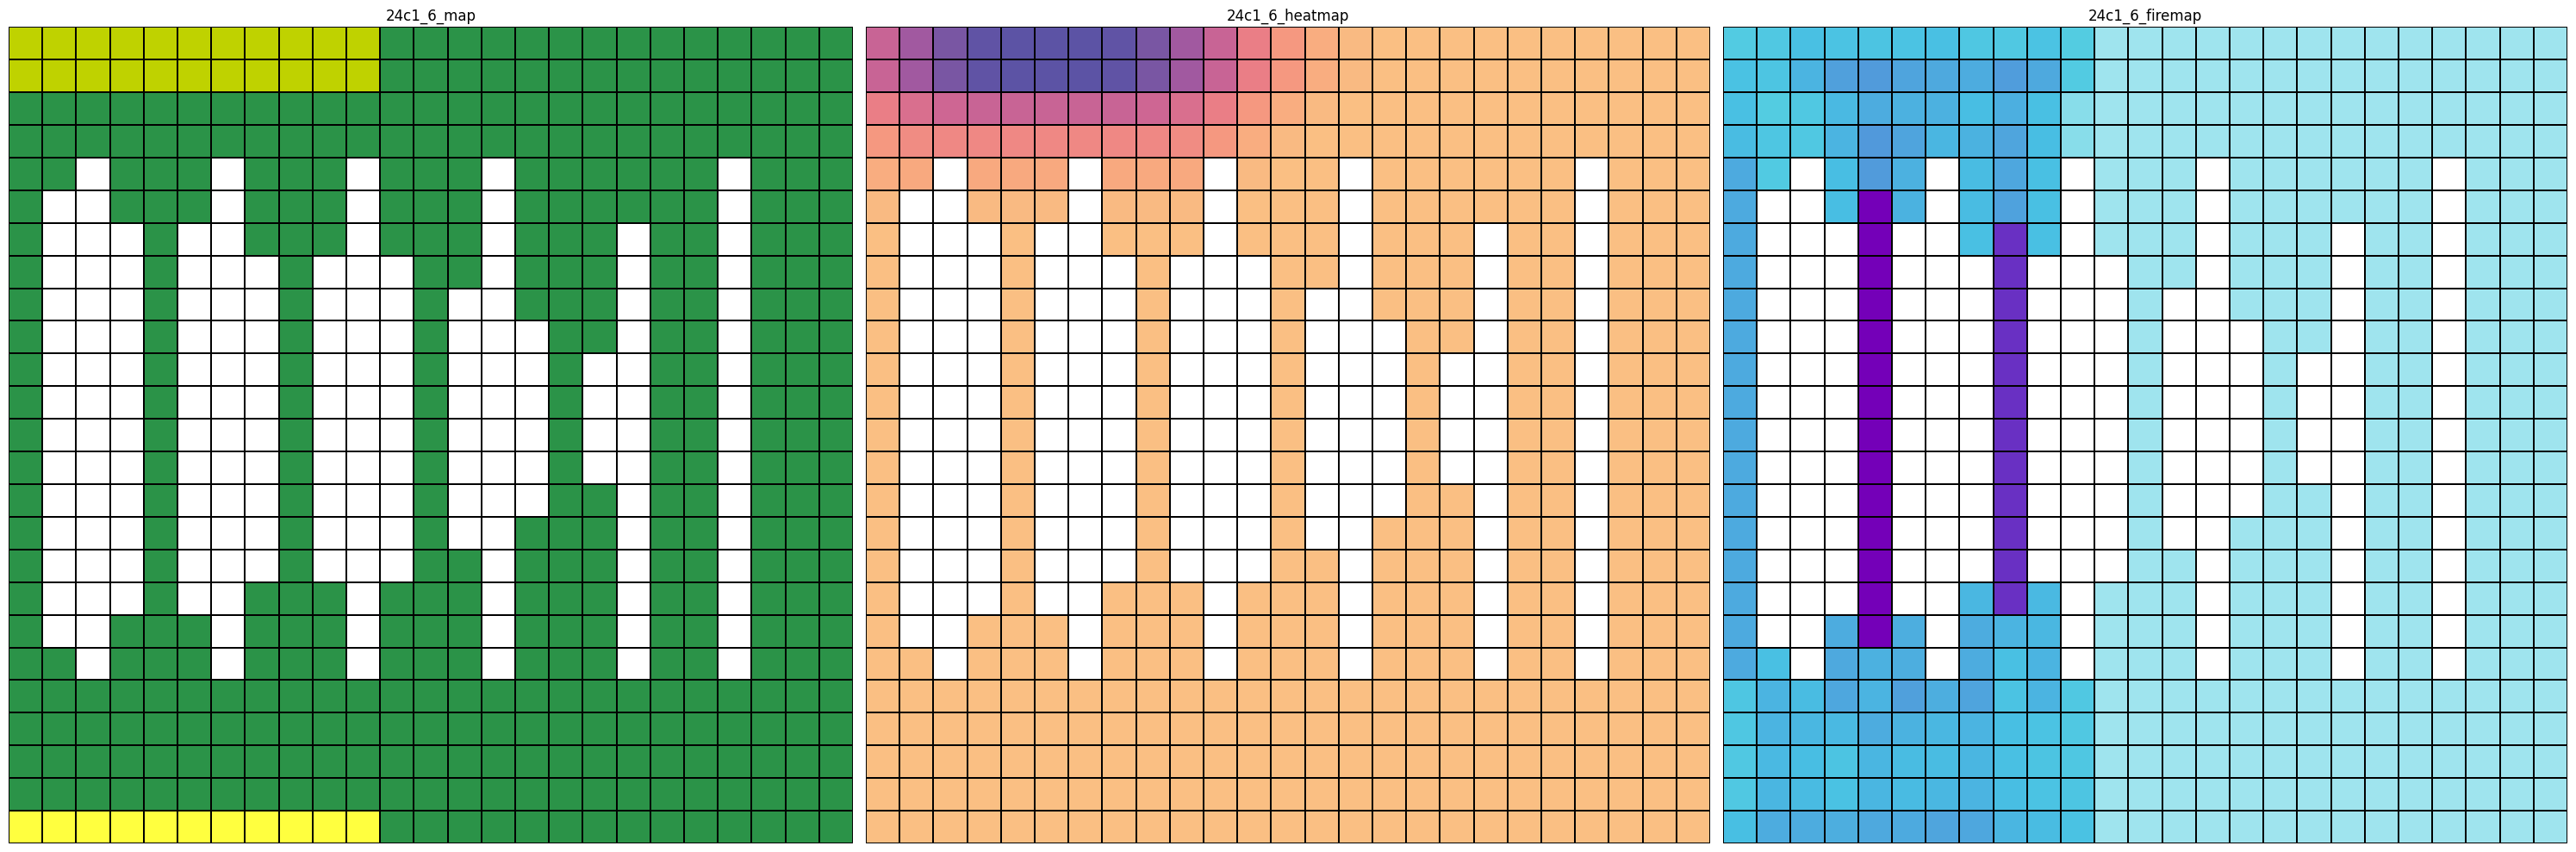

In [46]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


world_map_colors = ["#FFFFFF", "#2B9348", "#BFD200", "#FFFF3F"]
heatmap_colors = ["#FFFFFF",     "#fac484",     "#f8a07e",     "#eb7f86",     "#ce6693",     "#a059a0",     "#5c53a5",]
traffic_heatmap_colors = ["#7400b8", "#6930c3", "#5e60ce", "#5390d9", "#4ea8de", "#48bfe3", "#56cfe1",  "#FFFFFF"]

traffic_heatmap_colors.reverse()


world_map_palette = LinearSegmentedColormap.from_list("world_map_palette", world_map_colors, N=4)
heatmap_palette = LinearSegmentedColormap.from_list("heatmap_palette", heatmap_colors, N=100)
traffic_heatmap_palette = LinearSegmentedColormap.from_list("traffic_heatmap_palette", traffic_heatmap_colors, N=100)

map_name = "24c1_6"
palettes = [world_map_palette, heatmap_palette, traffic_heatmap_palette]
file_names = [f"{map_name}_map", f"{map_name}_heatmap", f"{map_name}_firemap"]

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

for ax, palette, file in zip(axes, palettes, file_names):
    with open(f"{file}.json", "r") as json_file:
        json_str = json_file.read()

    numeric_matrix = json.loads(json_str)
    numeric_matrix = [[int(element) for element in row] for row in numeric_matrix]
    numeric_matrix = np.rot90(np.array(numeric_matrix))

    sns.heatmap(
        numeric_matrix,
        cmap=palette,
        annot=False,
        cbar=False,
        linewidths=0.01,
        linecolor="black",
        ax=ax,
    )
    ax.set_title(file)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [66]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
import numpy as np

# Custom handler to create a gradient legend box
class HandlerColormap(HandlerPatch):
    def __init__(self, cmap, num_stripes=100, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        stripes = []
        for i in range(self.num_stripes):
            stripe = mpatches.Rectangle([xdescent + i * width / self.num_stripes, ydescent], 
                                        width / self.num_stripes, height, 
                                        transform=trans, 
                                        edgecolor='none', 
                                        facecolor=self.cmap(i / self.num_stripes))
            stripes.append(stripe)
        return stripes


def plot(map_name :str = "24c1_5"):
    world_map_colors = ["#FFFFFF", "#2B9348", "#BFD200", "#ff0000"]
    heatmap_colors = ["#ff0000","#ff4500","#ff8c00","#ffa500","#ffd700","#fffacd","#FFFFFF"]
    # traffic_heatmap_colors = ["#7400b8", "#6930c3", "#5e60ce", "#5390d9", "#4ea8de", "#48bfe3", "#56cfe1", "#FFFFFF"]
    traffic_heatmap_colors = ["#7400b8", "#6930c3", "#5e60ce", "#5390d9",  "#4ea8de", "#48bfe3", "#FFFFFF"]
    heatmap_colors.reverse()
    traffic_heatmap_colors.reverse()

    world_map_palette = LinearSegmentedColormap.from_list("world_map_palette", world_map_colors, N=4)
    heatmap_palette = LinearSegmentedColormap.from_list("heatmap_palette", heatmap_colors, N=len(heatmap_colors))
    traffic_heatmap_palette = LinearSegmentedColormap.from_list("traffic_heatmap_palette", traffic_heatmap_colors, N=100)

    palettes = [world_map_palette, heatmap_palette, traffic_heatmap_palette]
    file_names = [f'{map_name}_map', f'{map_name}_heatmap', f'{map_name}_firemap']
    colors = [world_map_colors, heatmap_colors, traffic_heatmap_colors]

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(30, 10))

    for ax, palette, file, color in zip(axes, palettes, file_names, colors):
        with open(f'{file}.json', 'r') as json_file:
            json_str = json_file.read()

        numeric_matrix = json.loads(json_str)
        numeric_matrix = [[int(element) for element in row] for row in numeric_matrix]
        numeric_matrix = np.rot90(np.array(numeric_matrix))

        if file == f'{map_name}_heatmap':
            min_val = np.min(numeric_matrix)
            max_val = np.max(numeric_matrix)
            numeric_matrix = (numeric_matrix - min_val) / (max_val - min_val)

            color_matrix = np.empty(numeric_matrix.shape, dtype=int)

            for i in range(numeric_matrix.shape[0]):
                for j in range(numeric_matrix.shape[1]):
                    normalized_value = numeric_matrix[i, j]
                    color_index = np.clip(int(normalized_value * (len(color) - 1)), 0, len(color) - 1)
                    color_matrix[i, j] = color_index

            numeric_matrix = color_matrix

        # print(numeric_matrix)

        sns.heatmap(numeric_matrix, cmap=palette, annot=False, cbar=False, square=True, linewidths=0.01, linecolor='black', ax=ax)
        
        ax.set_title(file, fontsize=18) 
        ax.set_xticks([])
        ax.set_yticks([])

        # Add custom labels
        if file == f'{map_name}_map':
            labels = {
                "#FFFFFF": "Non-Walkable Tiles",
                "#2B9348": "Walkable Tiles",
                "#BFD200": "Spawn Tiles",
                "#ff0000": "Delivery Tiles"
            }
            patches = [mpatches.Patch(color=color, label=label) for color, label in labels.items()]
            ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(0.999, 0.999), borderaxespad=0, fontsize=15)
        else:
            gradient_legend_patch = mpatches.Patch(color='none', label='Higher values are darker')
            non_walkable_patch = mpatches.Patch(color="#FFFFFF", label="Non-Walkable")
            
            handler_cmap = HandlerColormap(heatmap_palette if file == f'{map_name}_heatmap' else traffic_heatmap_palette)
        
            ax.legend(handles=[non_walkable_patch, gradient_legend_patch], 
            handler_map={gradient_legend_patch: handler_cmap, non_walkable_patch: HandlerPatch()}, 
            loc='upper right', bbox_to_anchor=(0.999, 0.999), borderaxespad=0, fontsize=15)

    plt.tight_layout()
    # plt.show()
    plt.savefig(f'{map_name}.png', dpi=300, bbox_inches="tight")


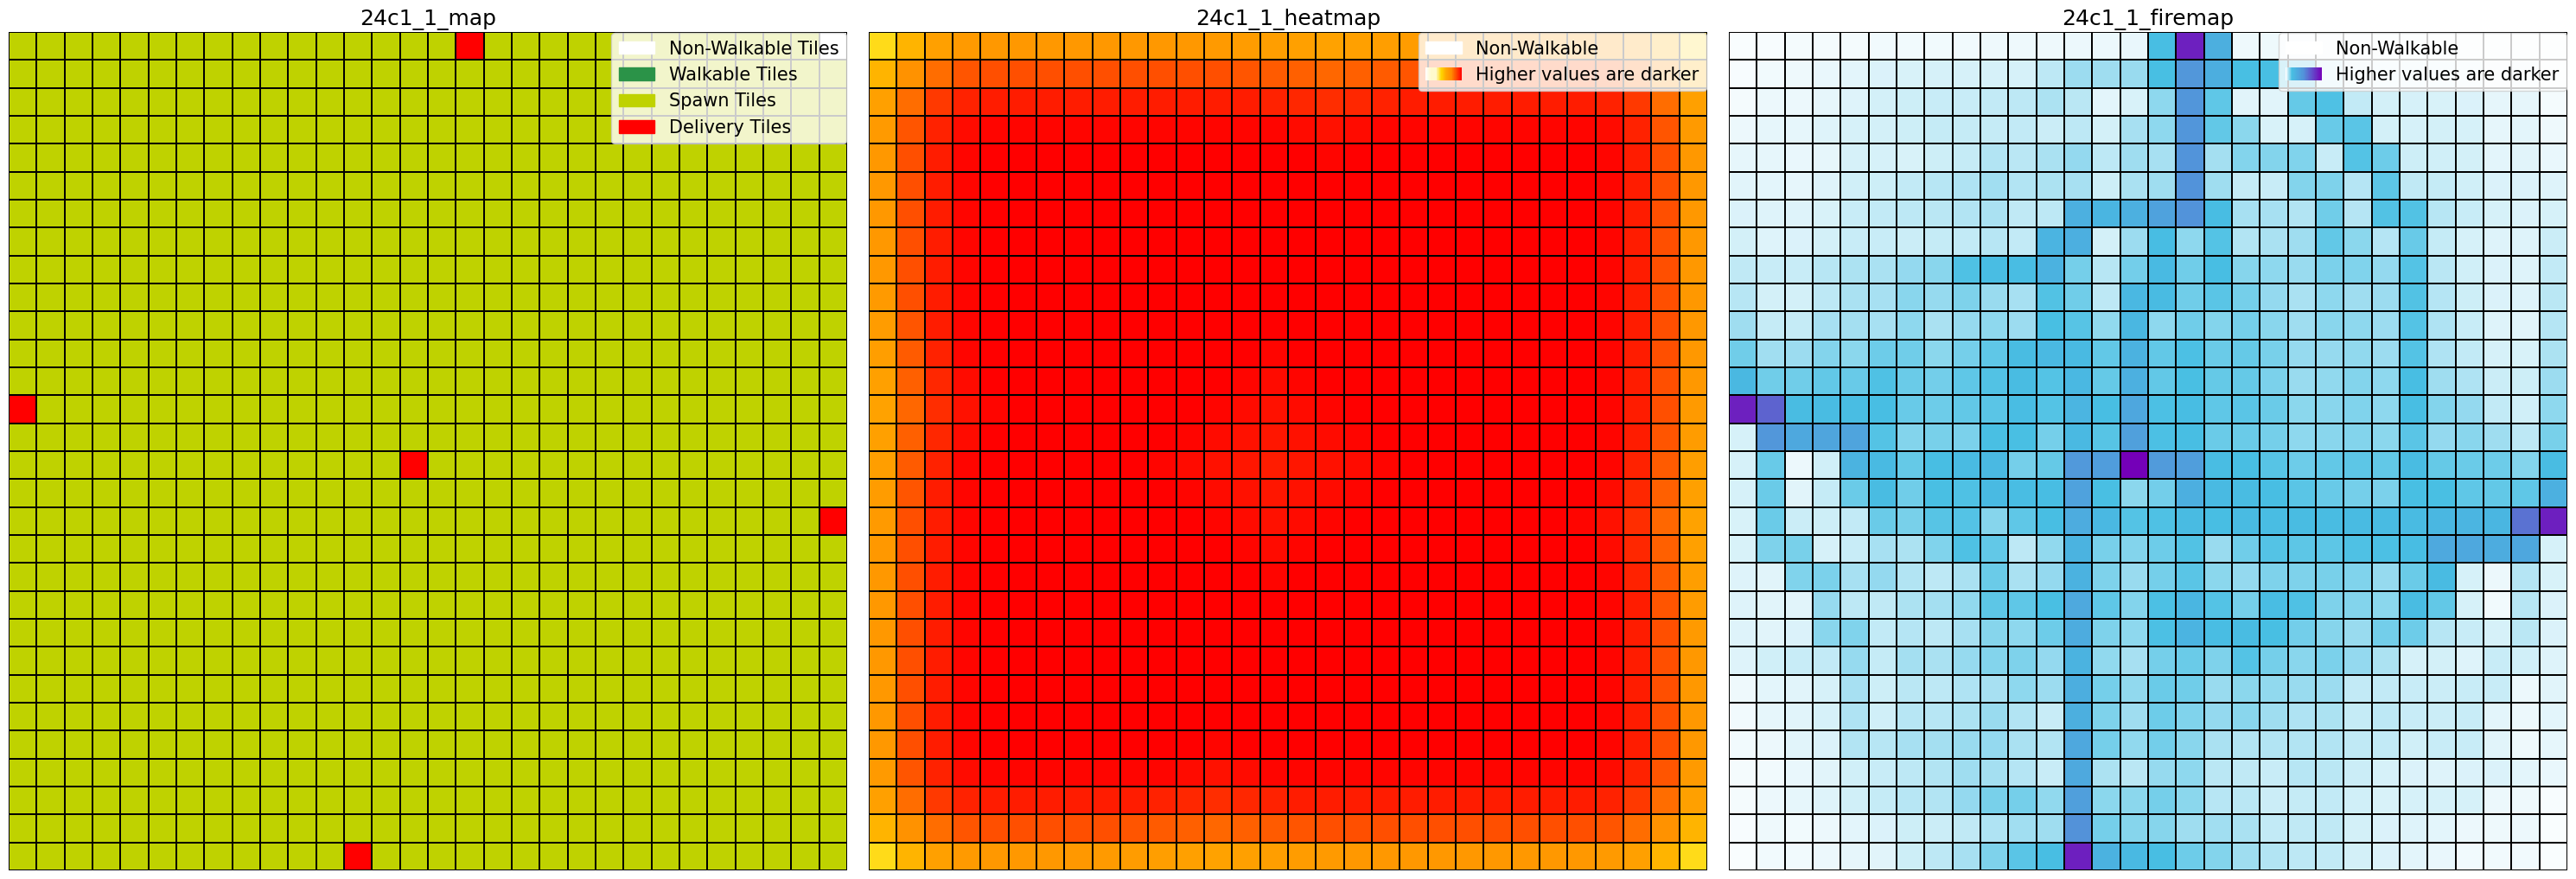

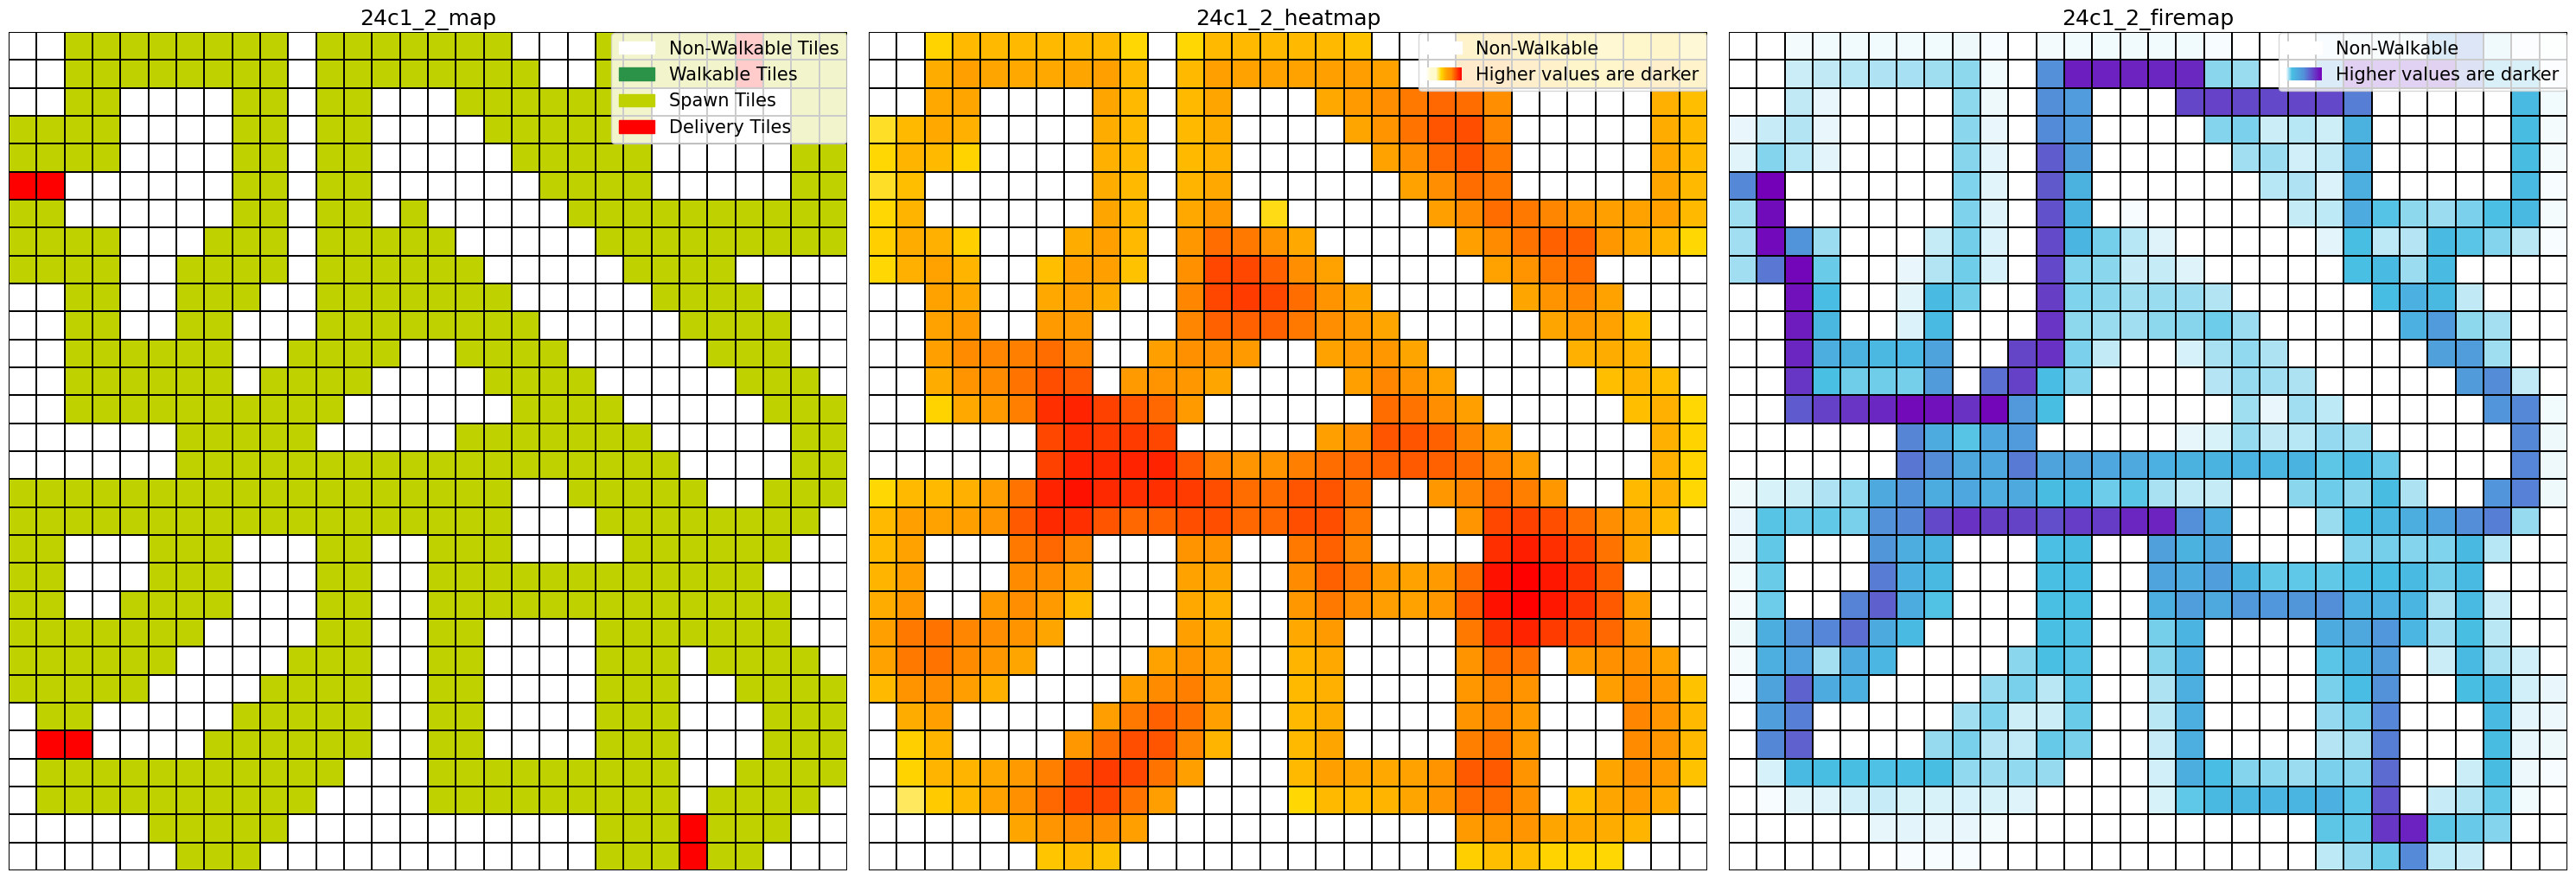

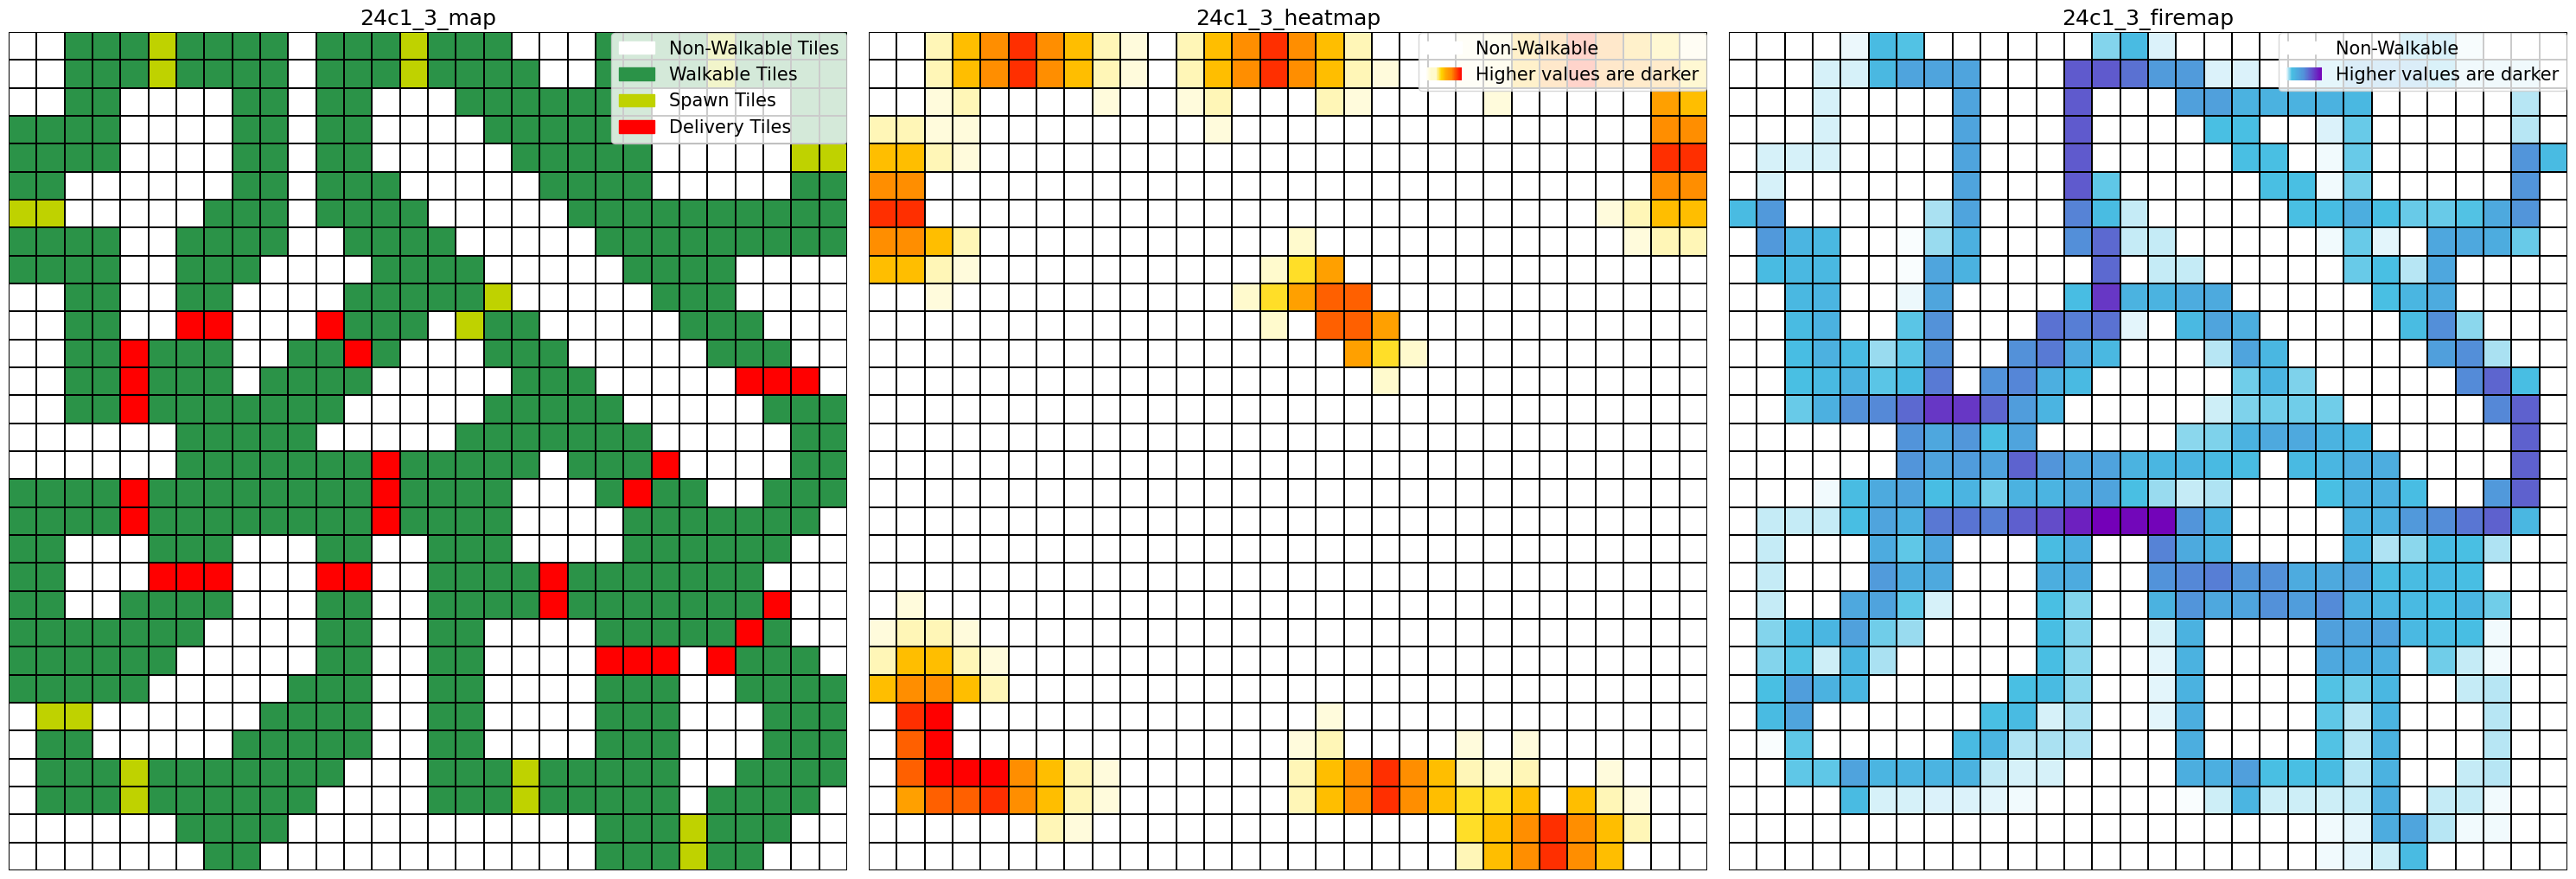

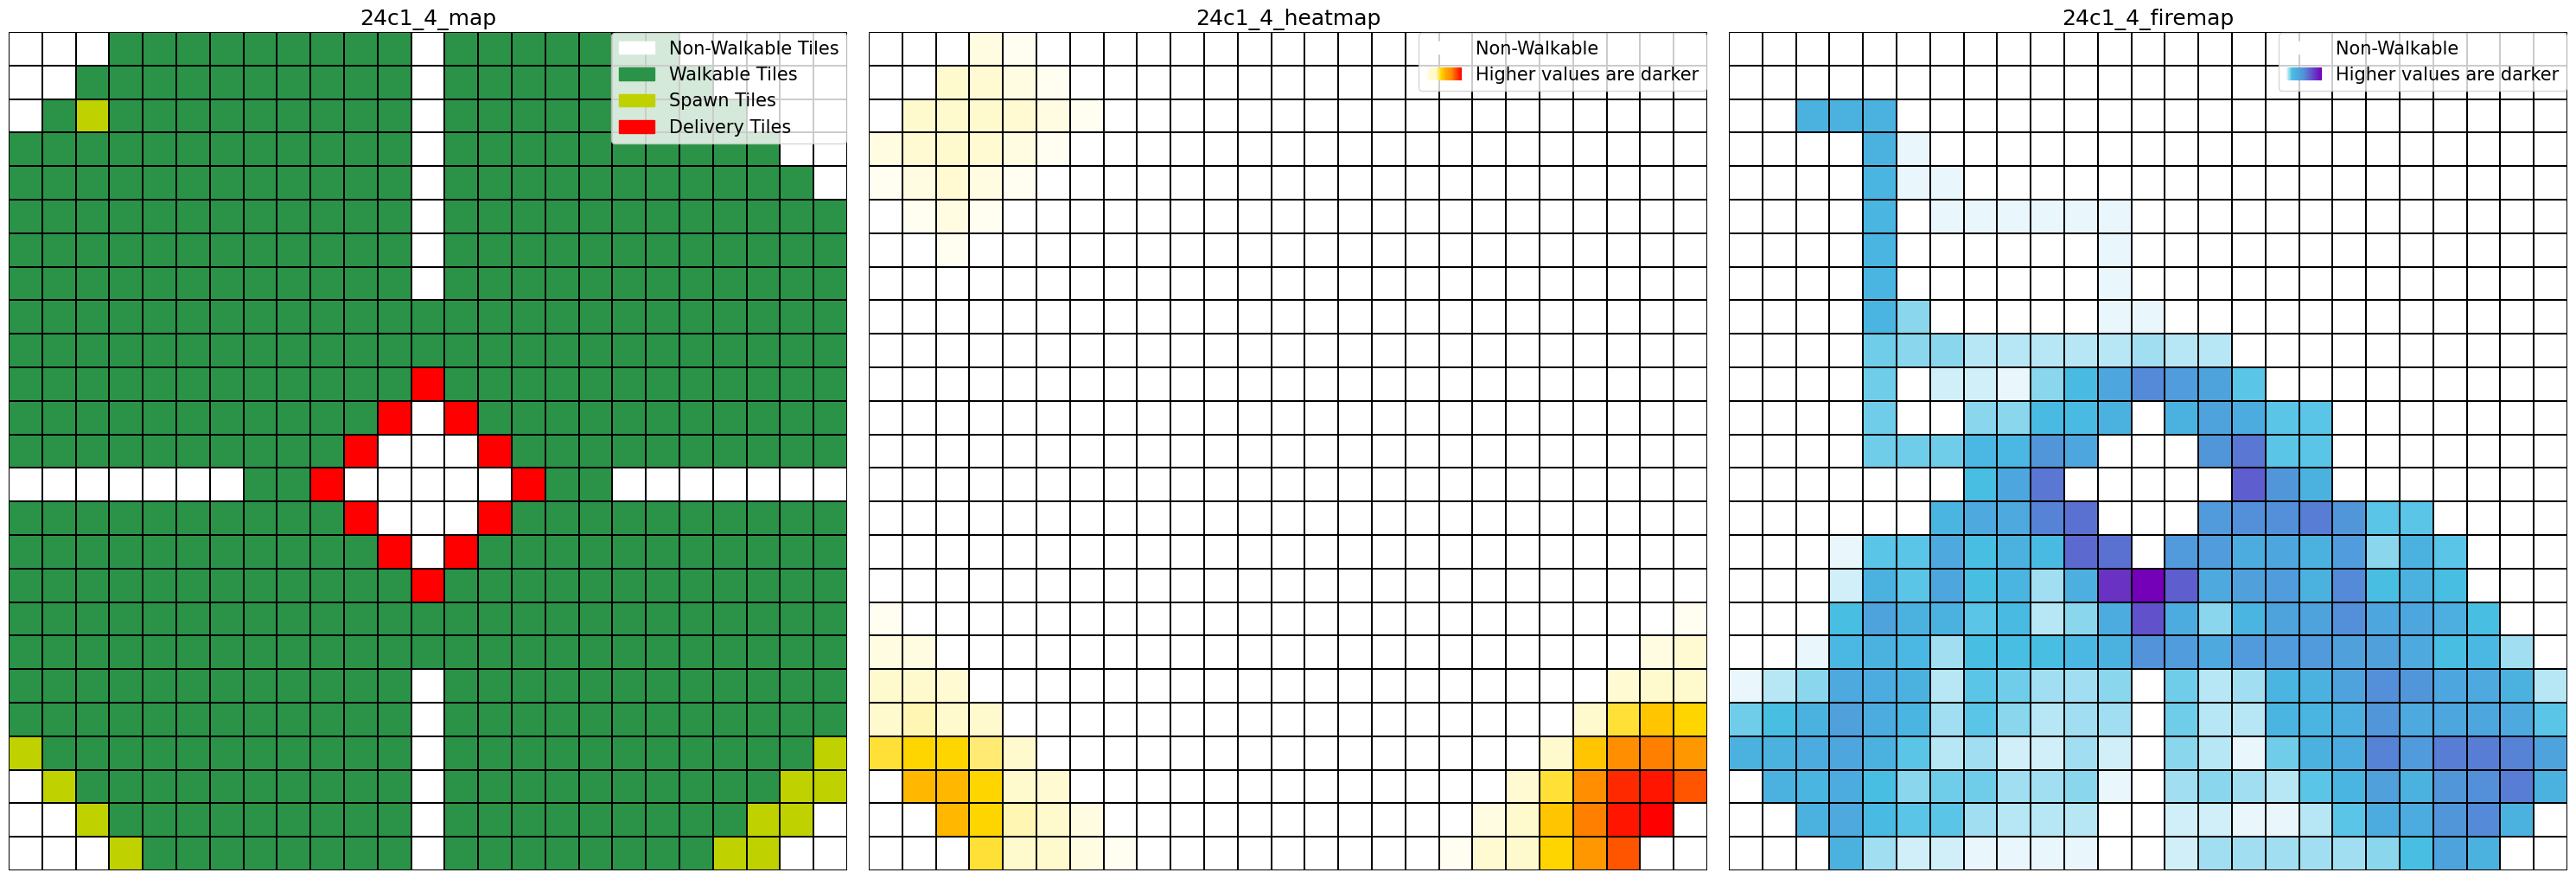

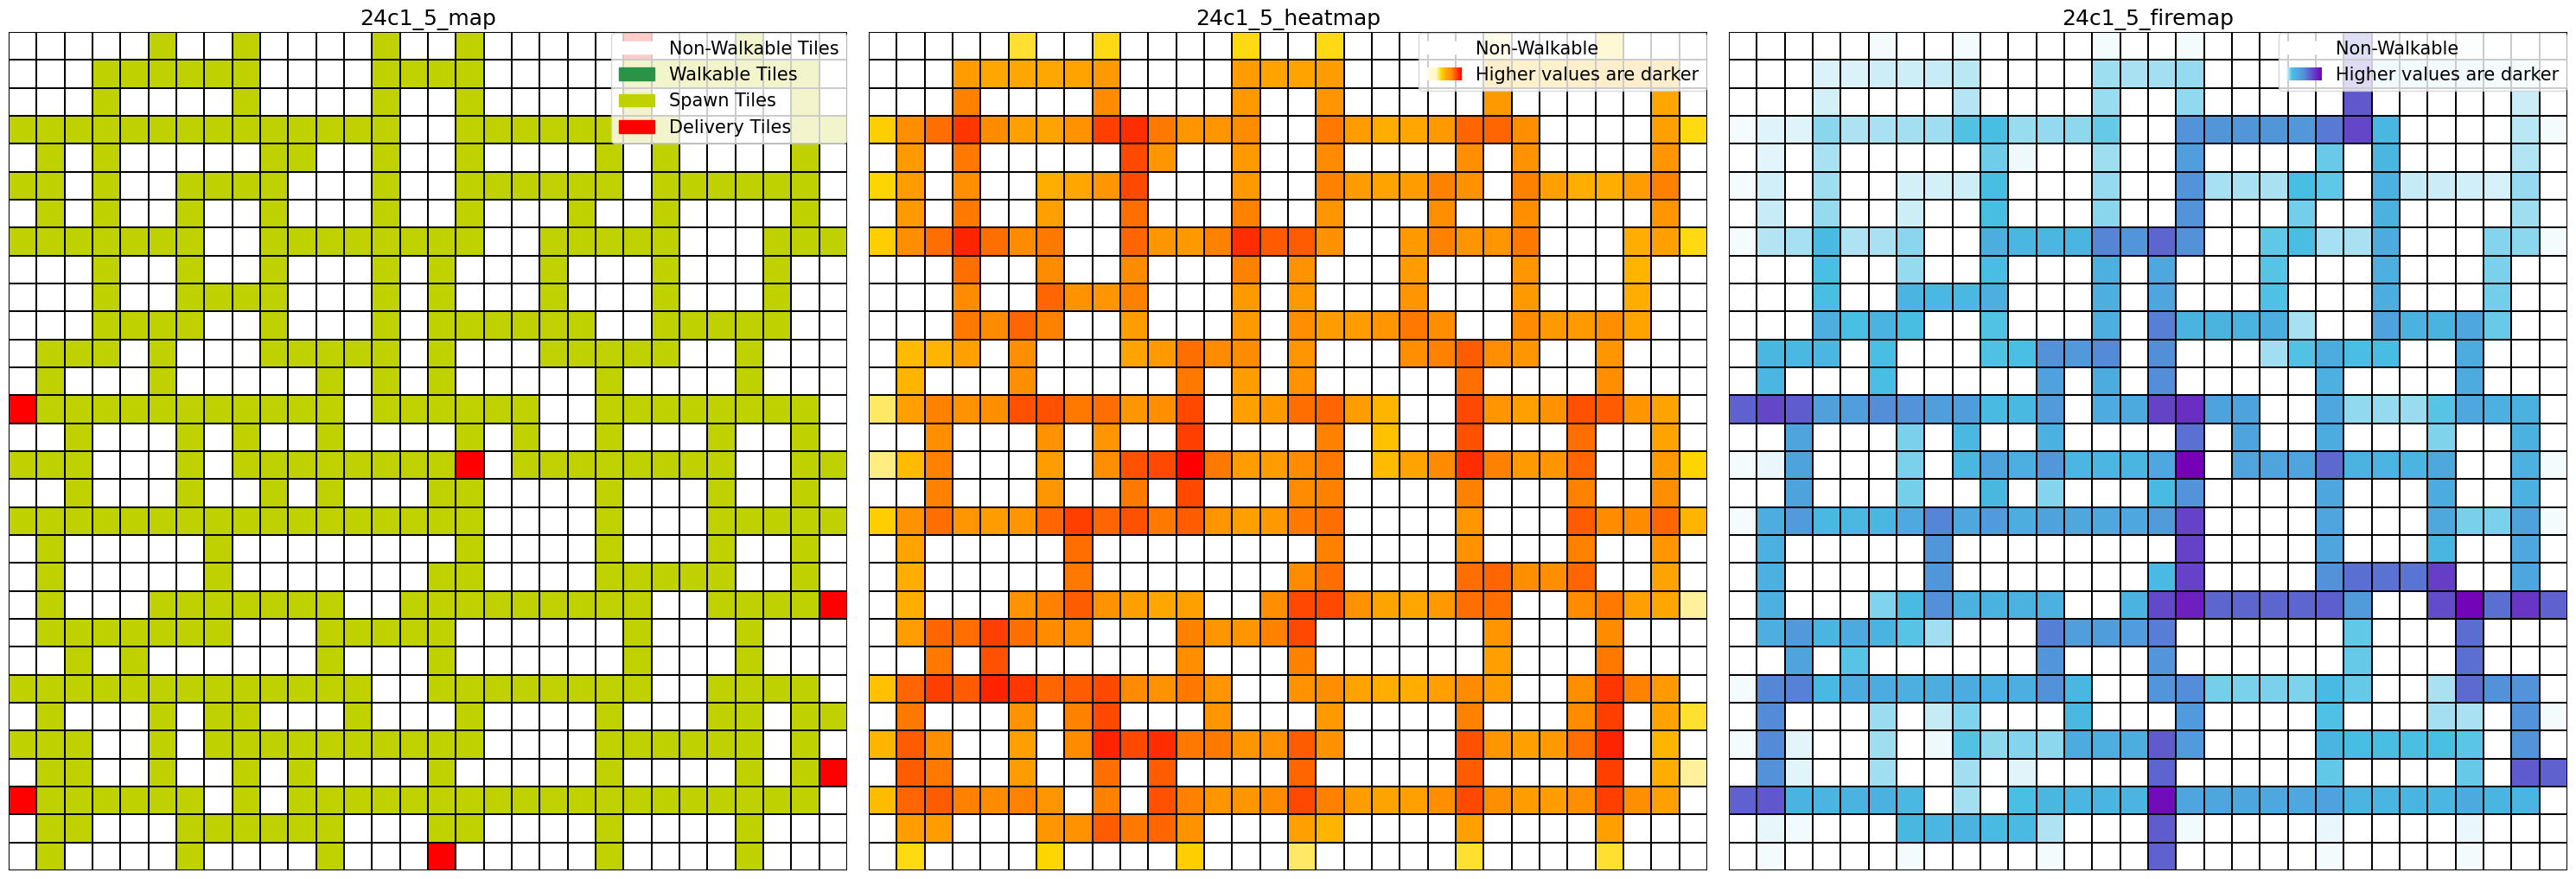

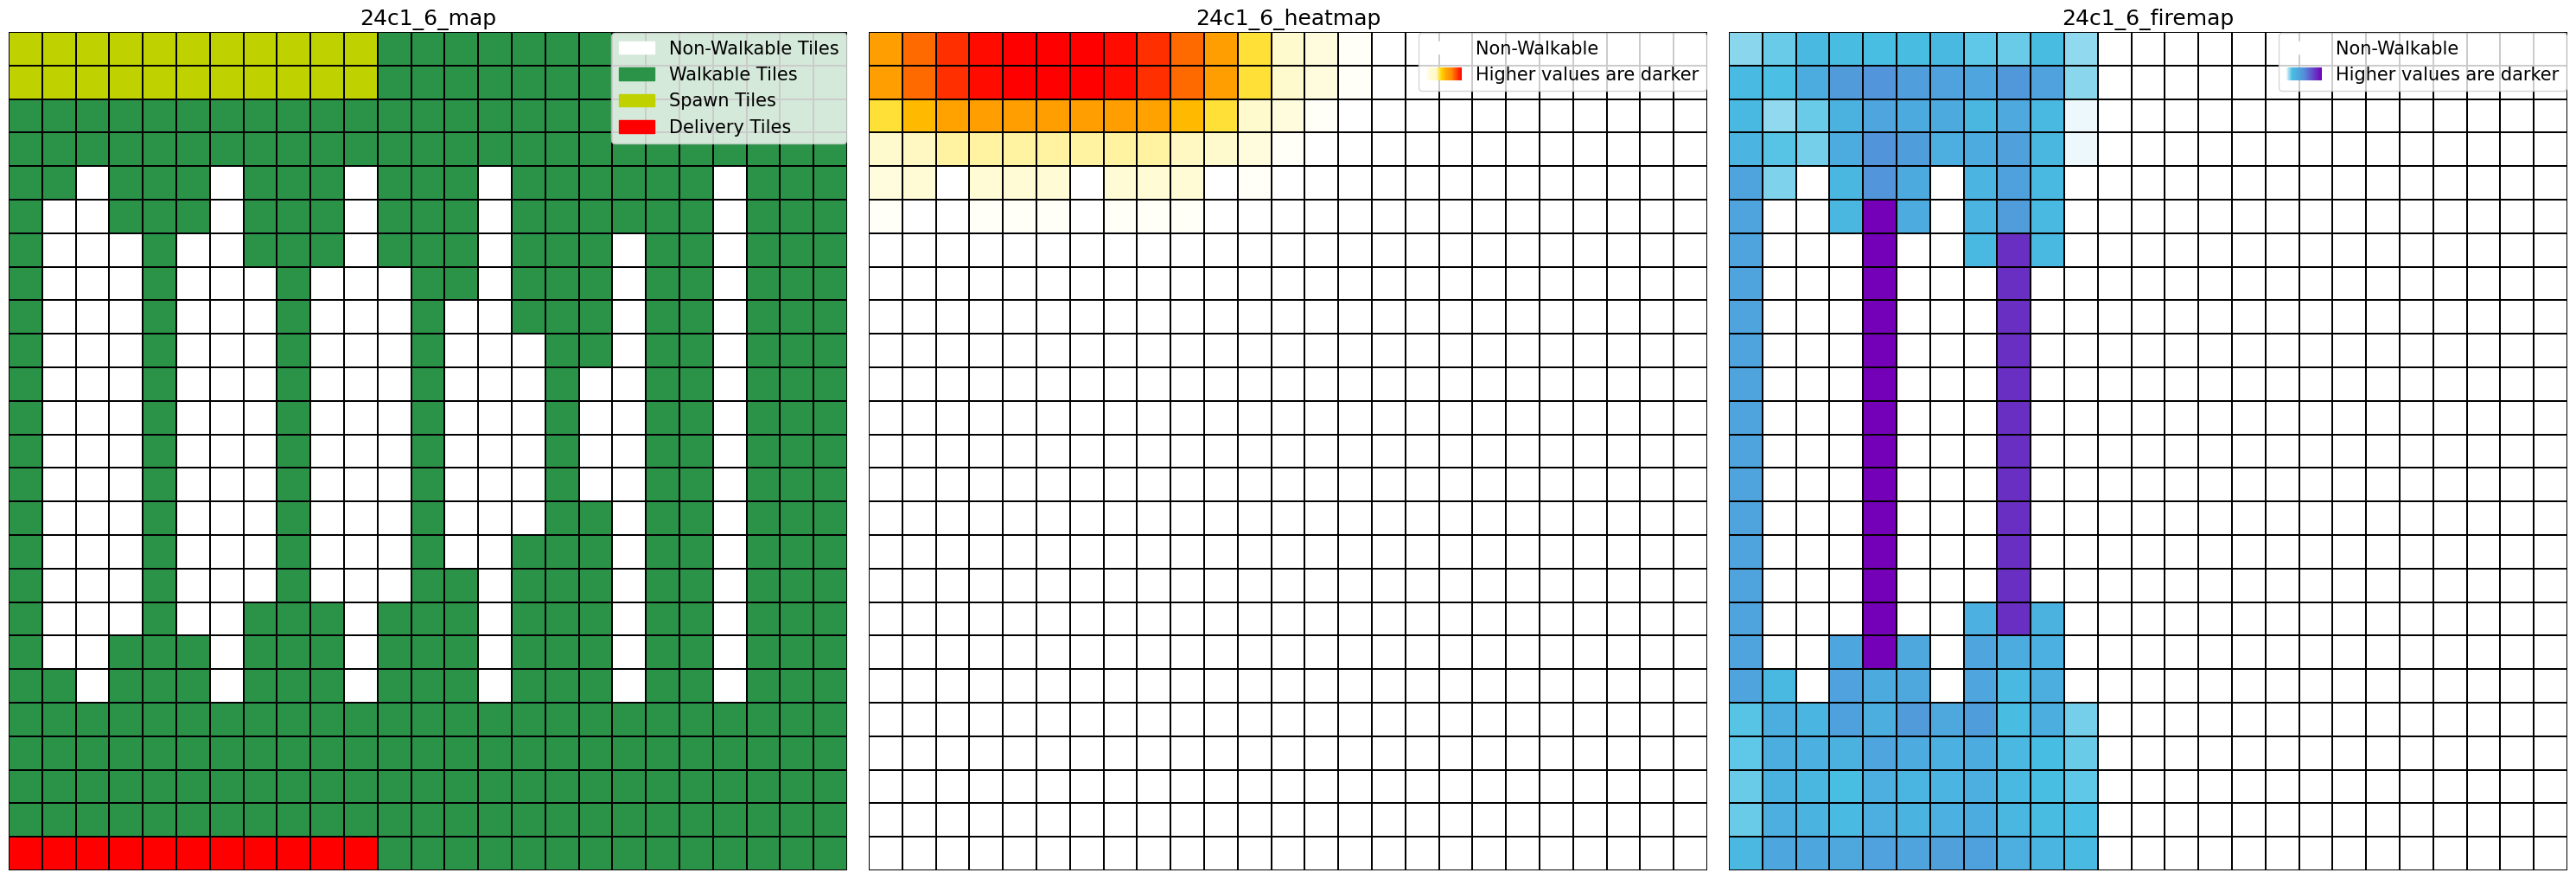

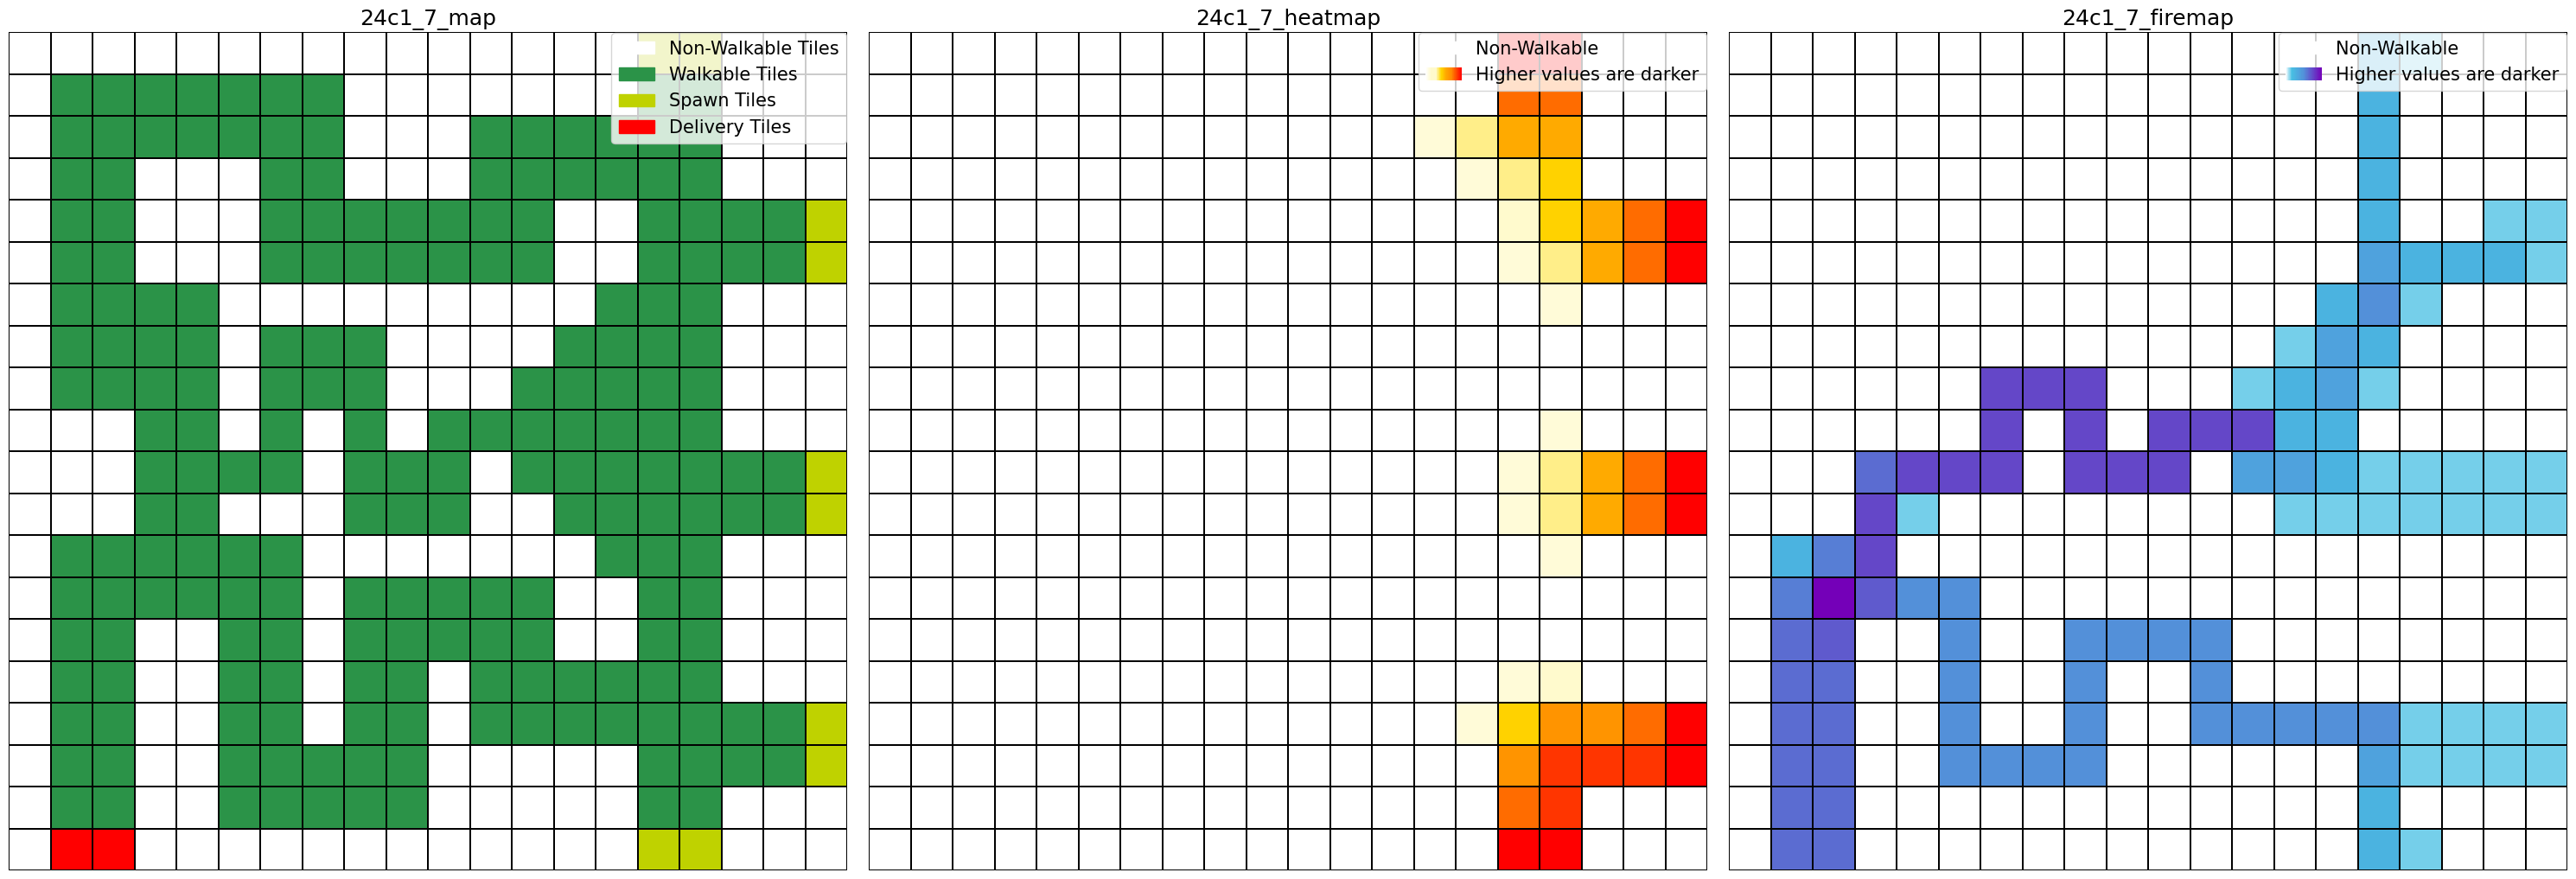

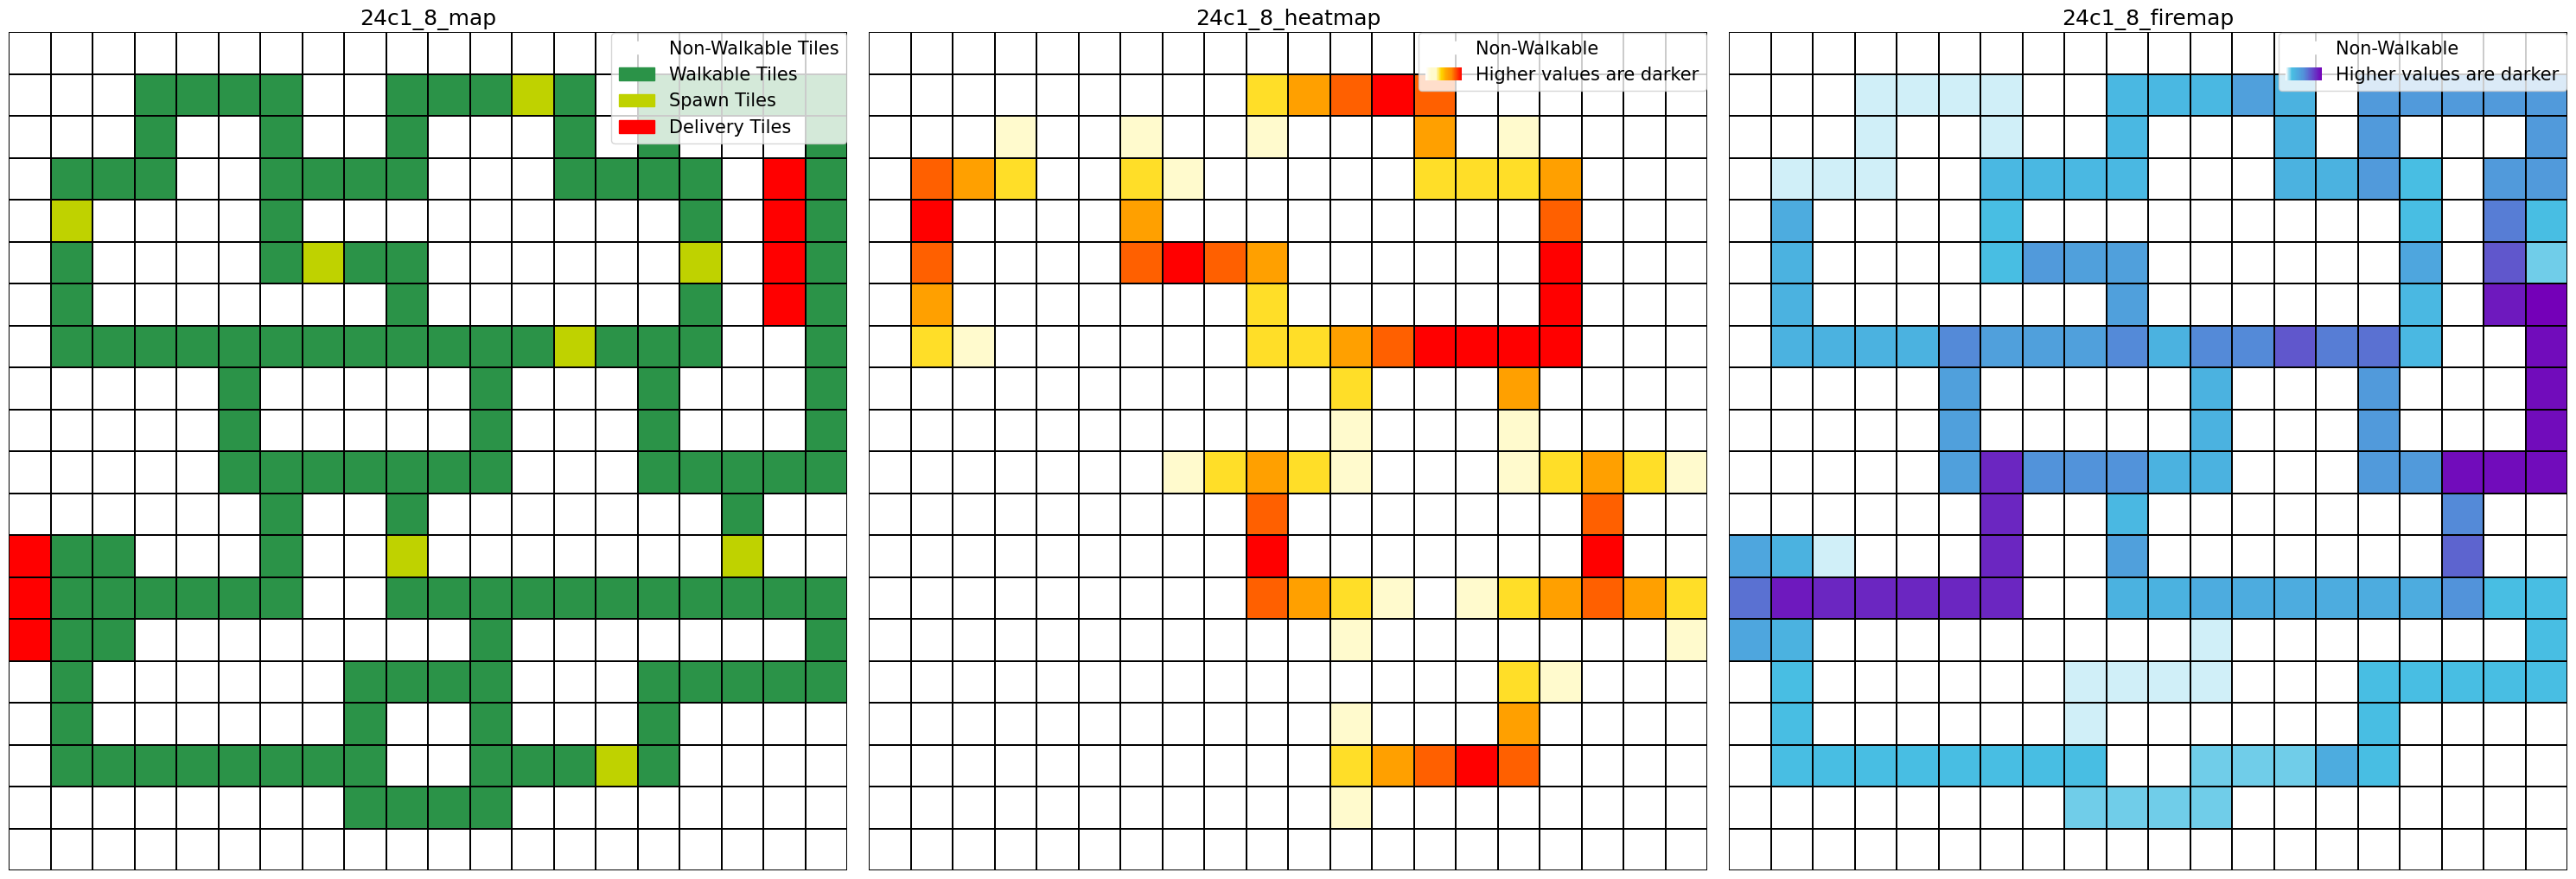

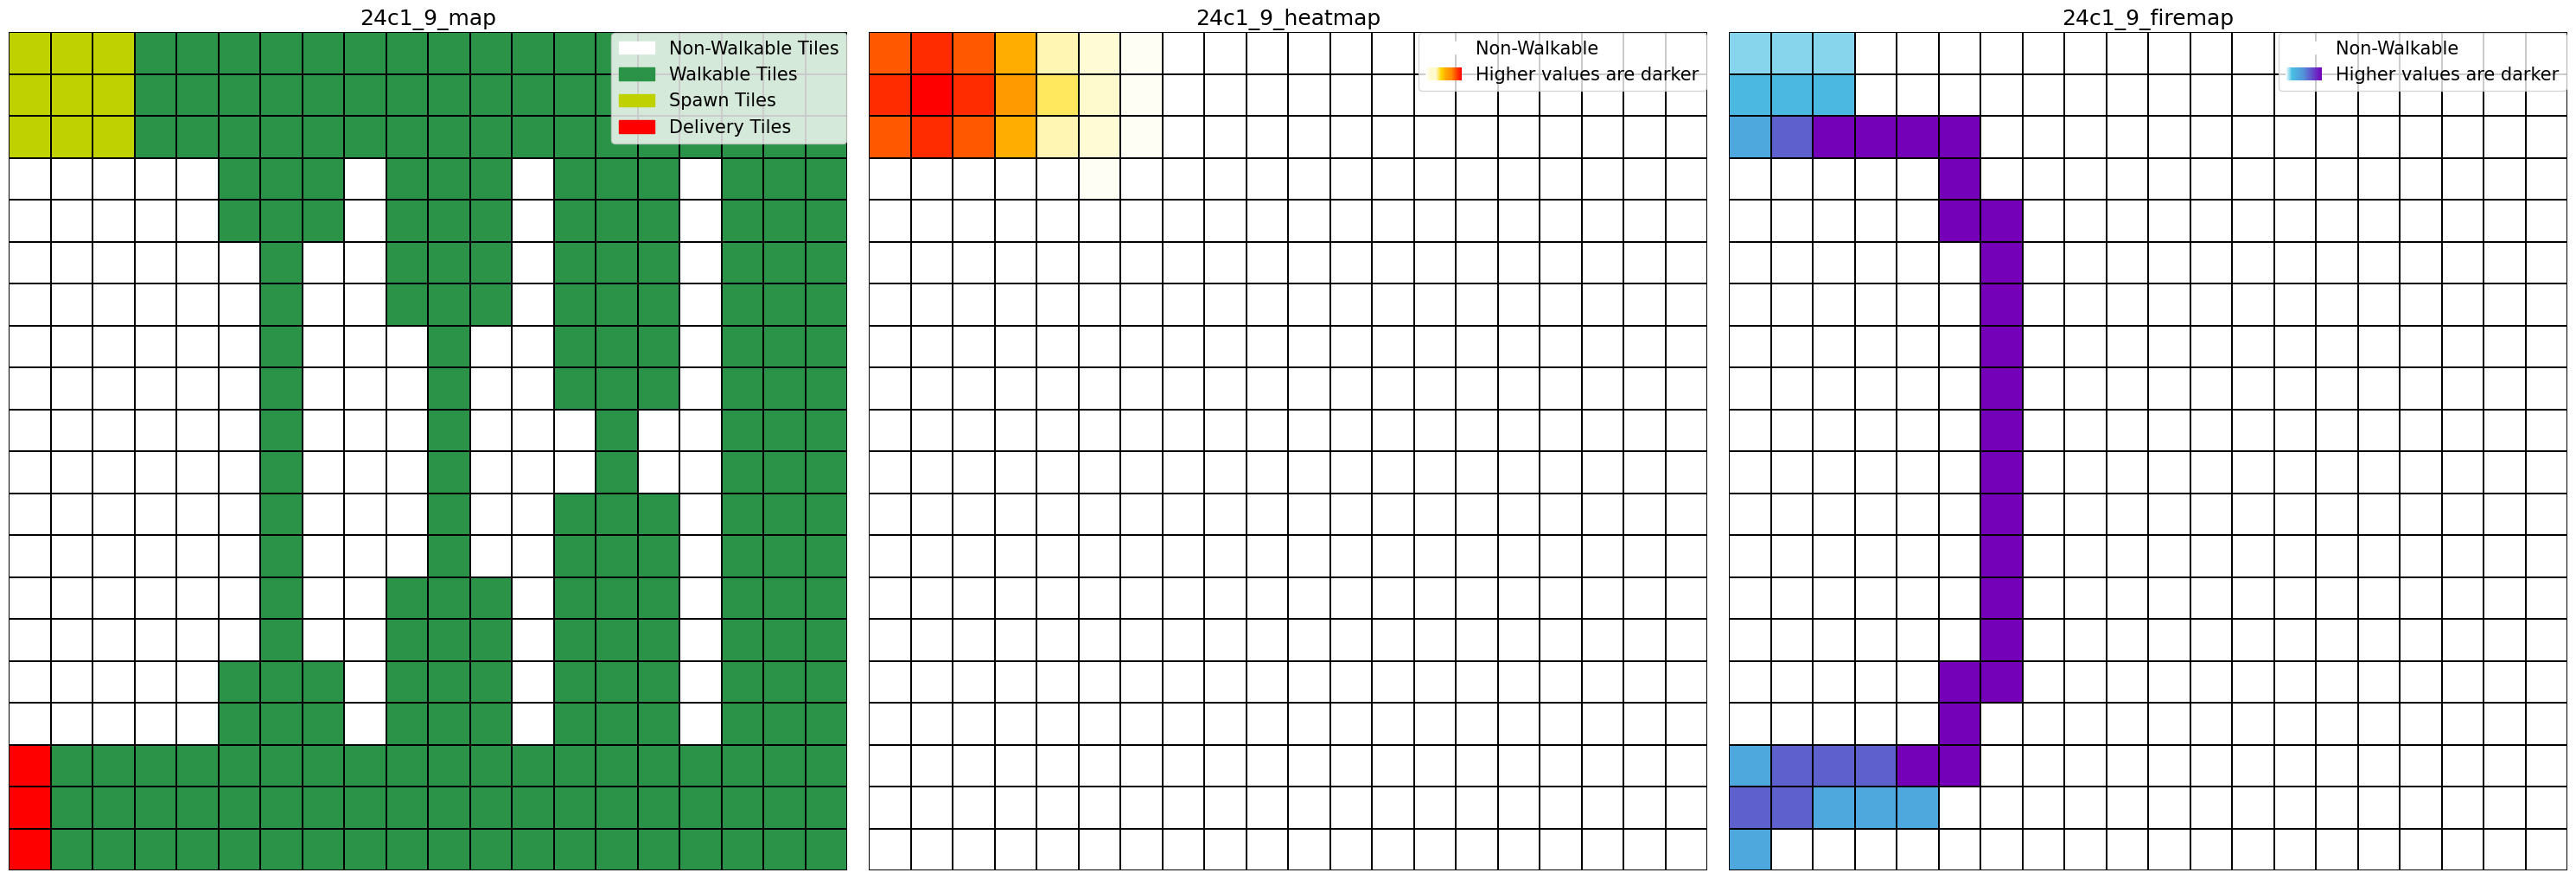

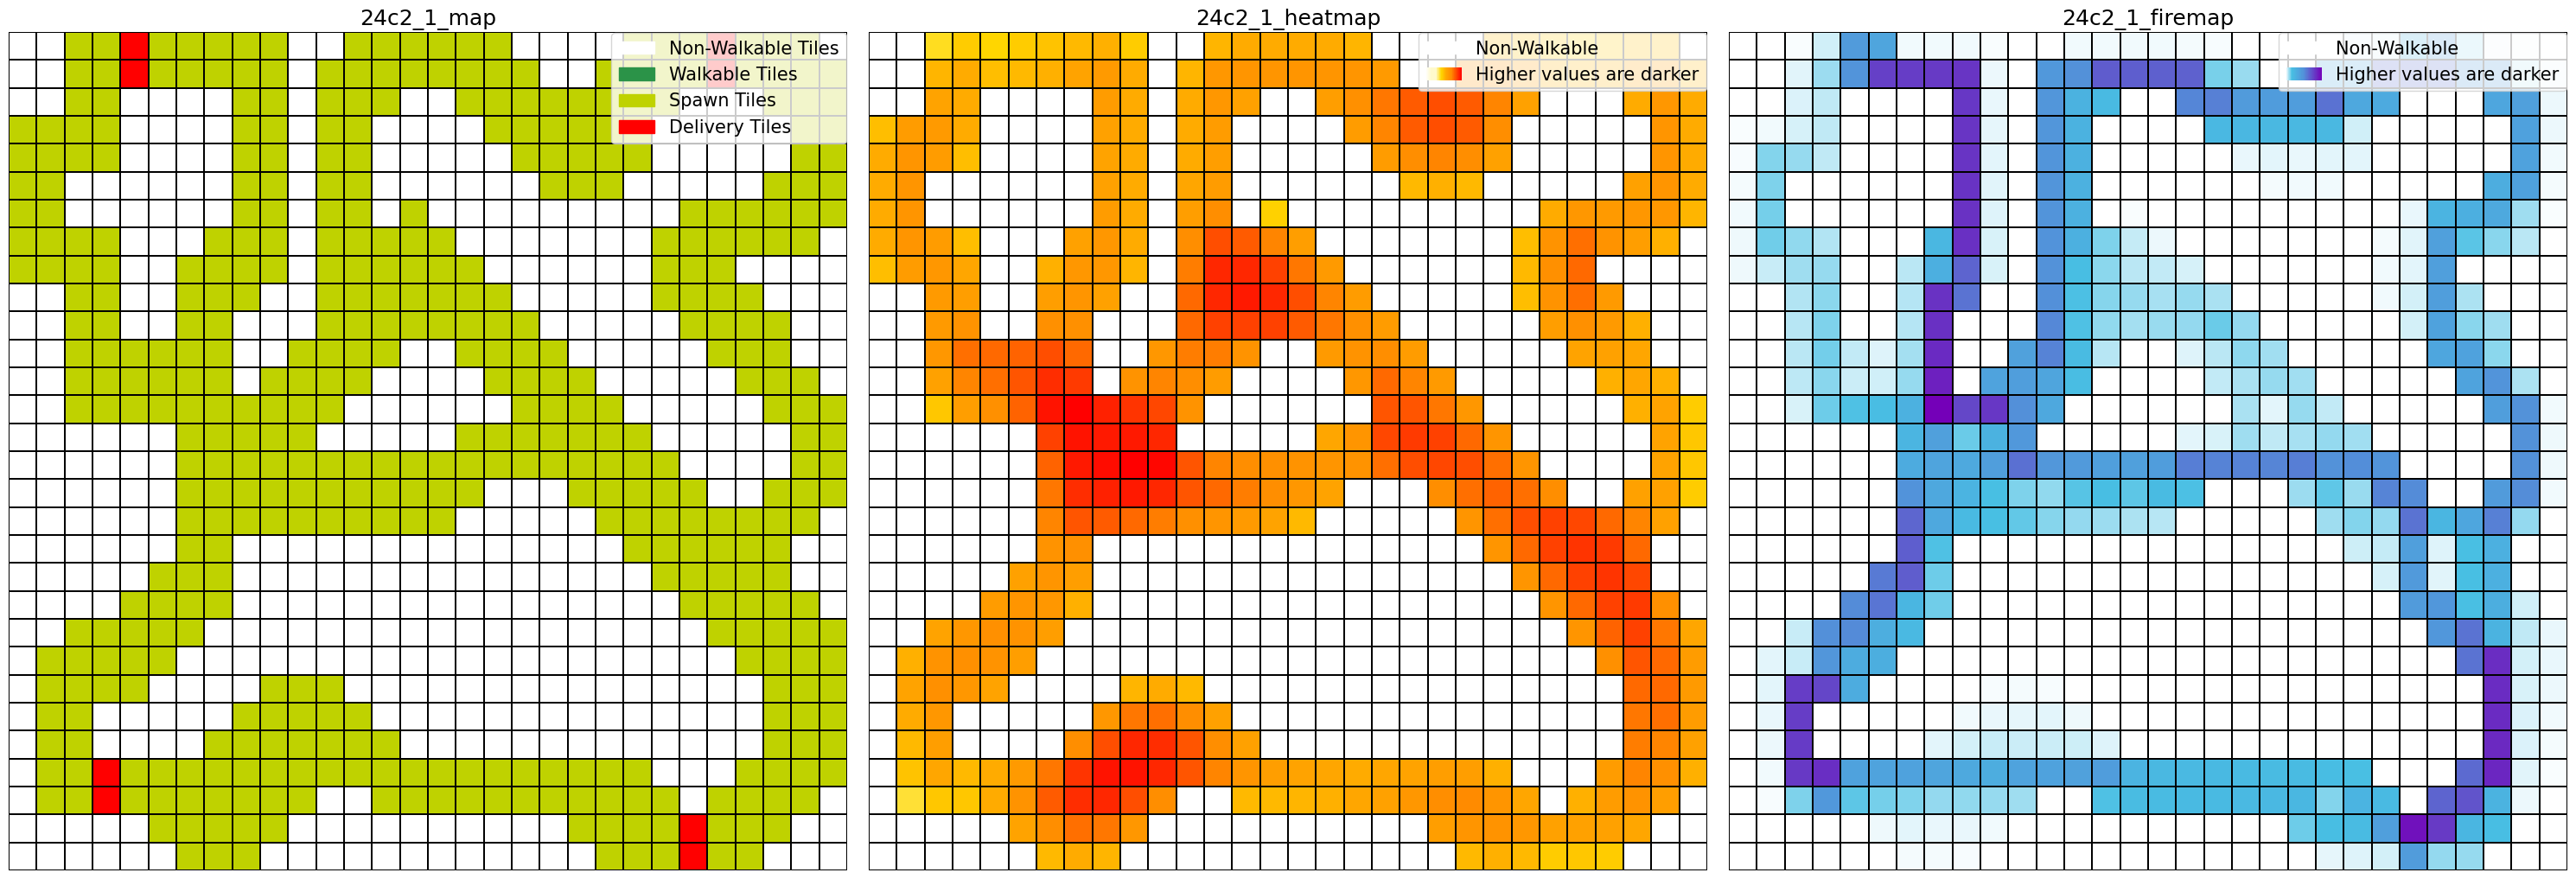

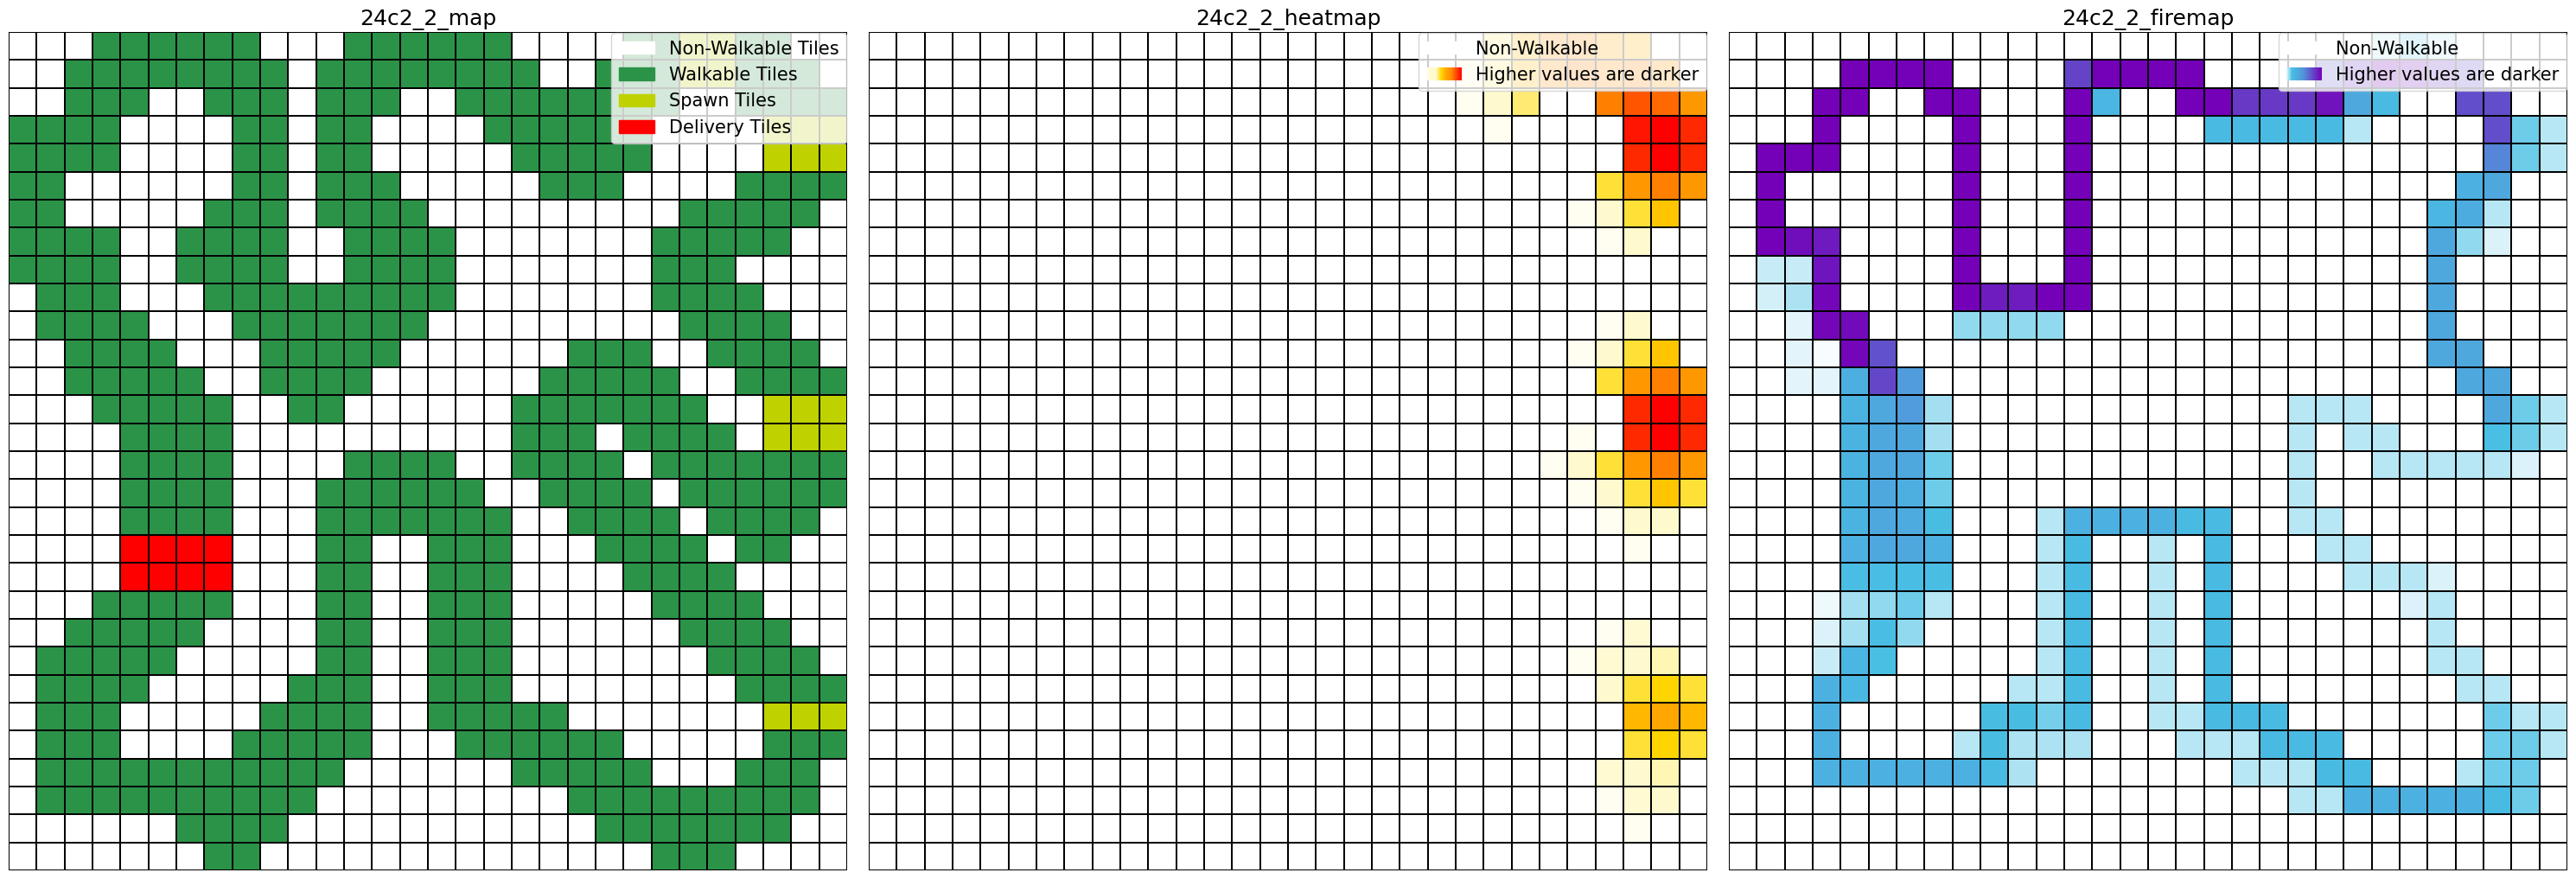

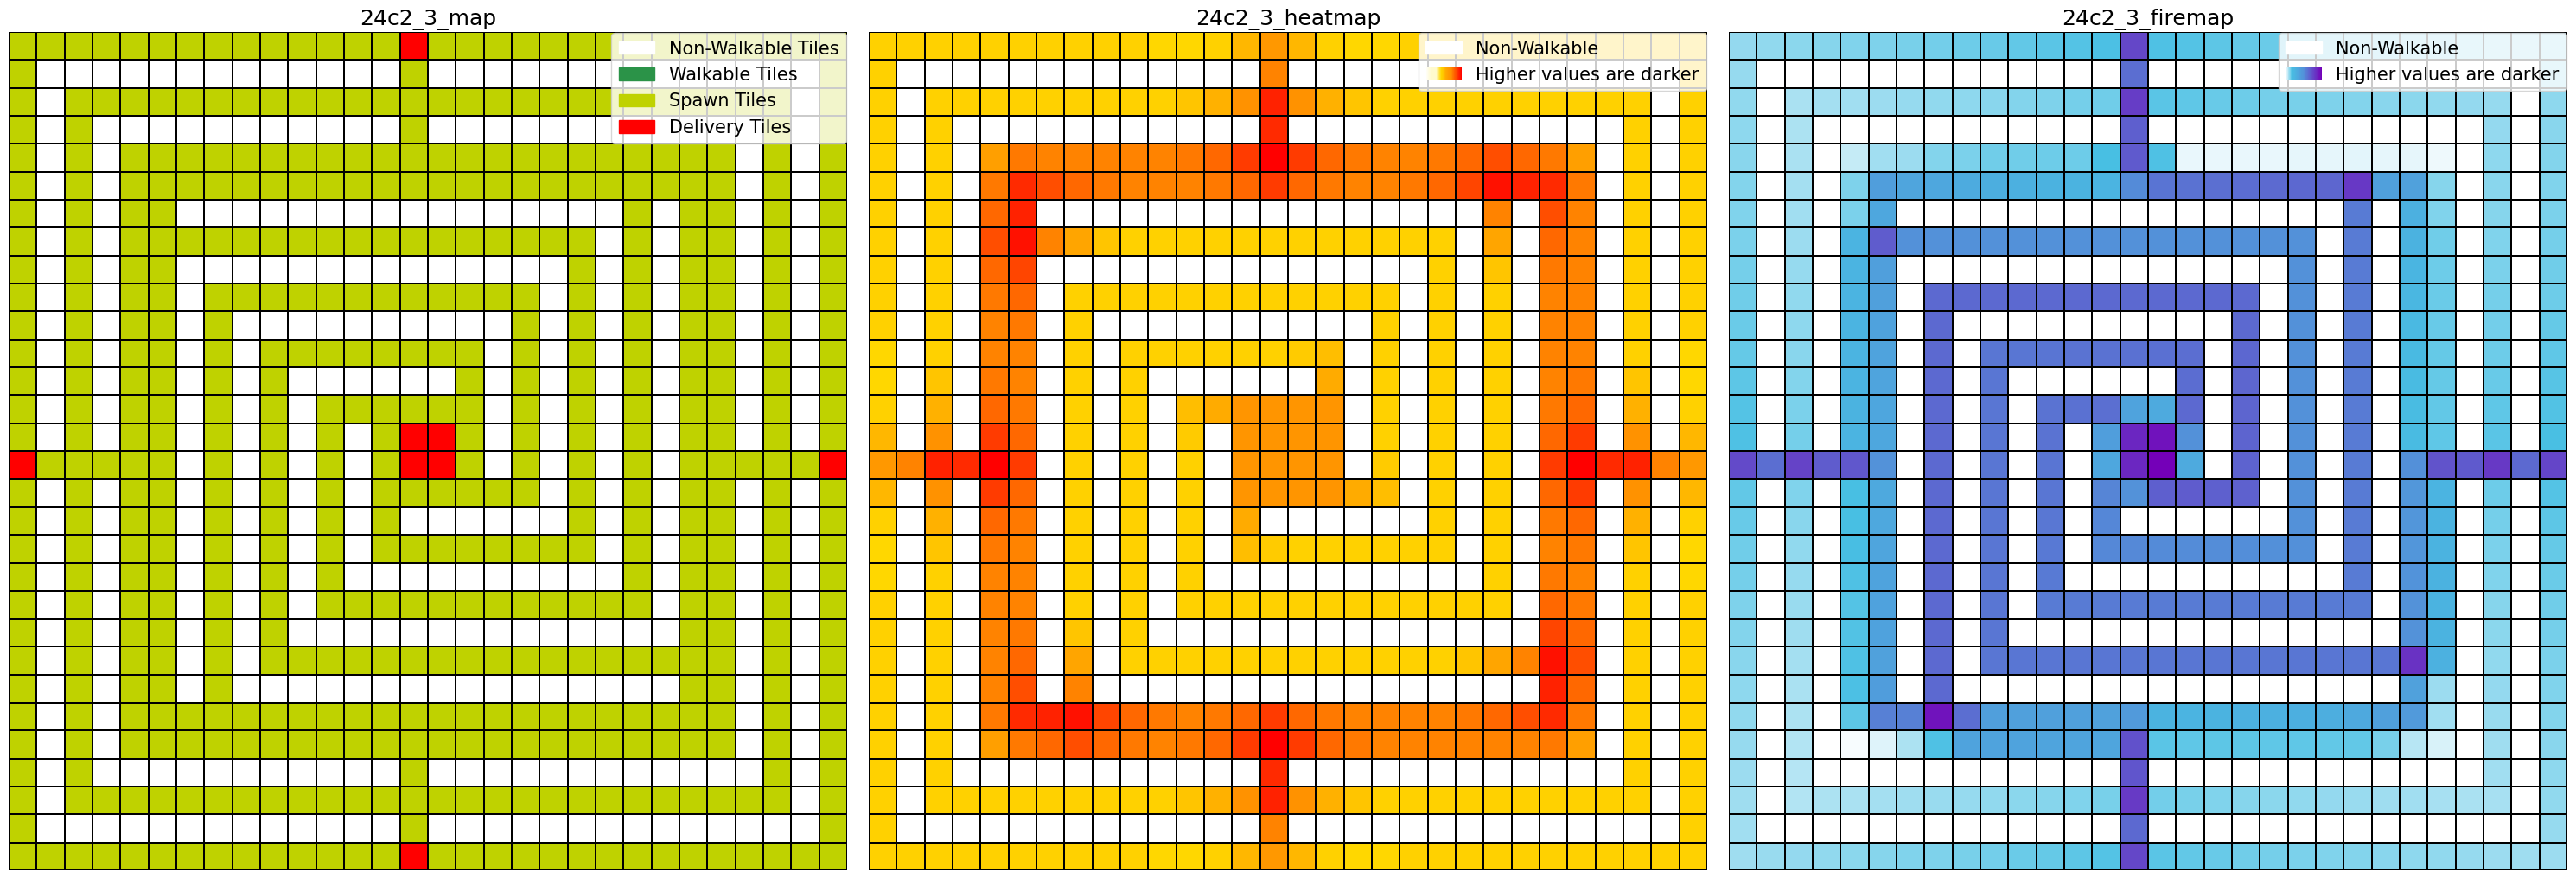

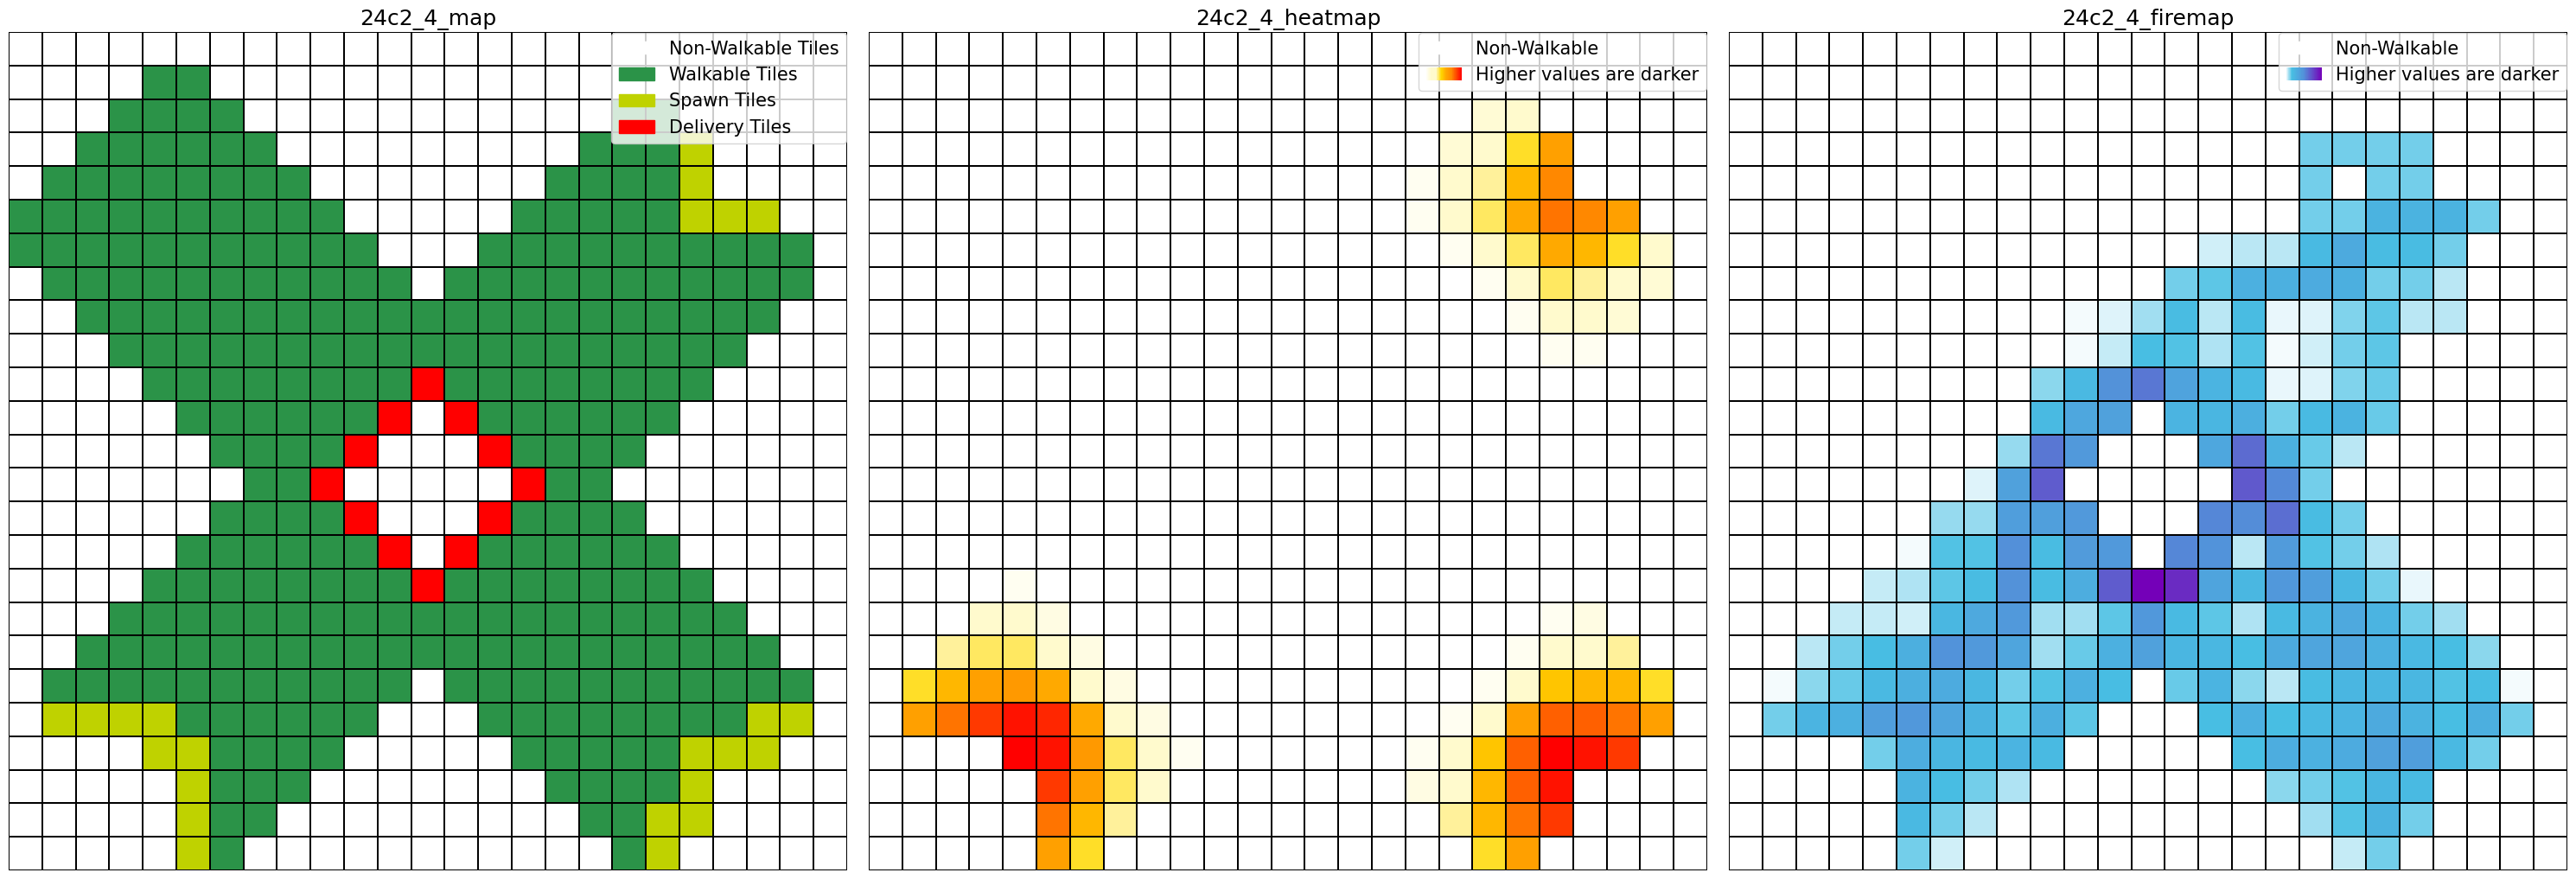

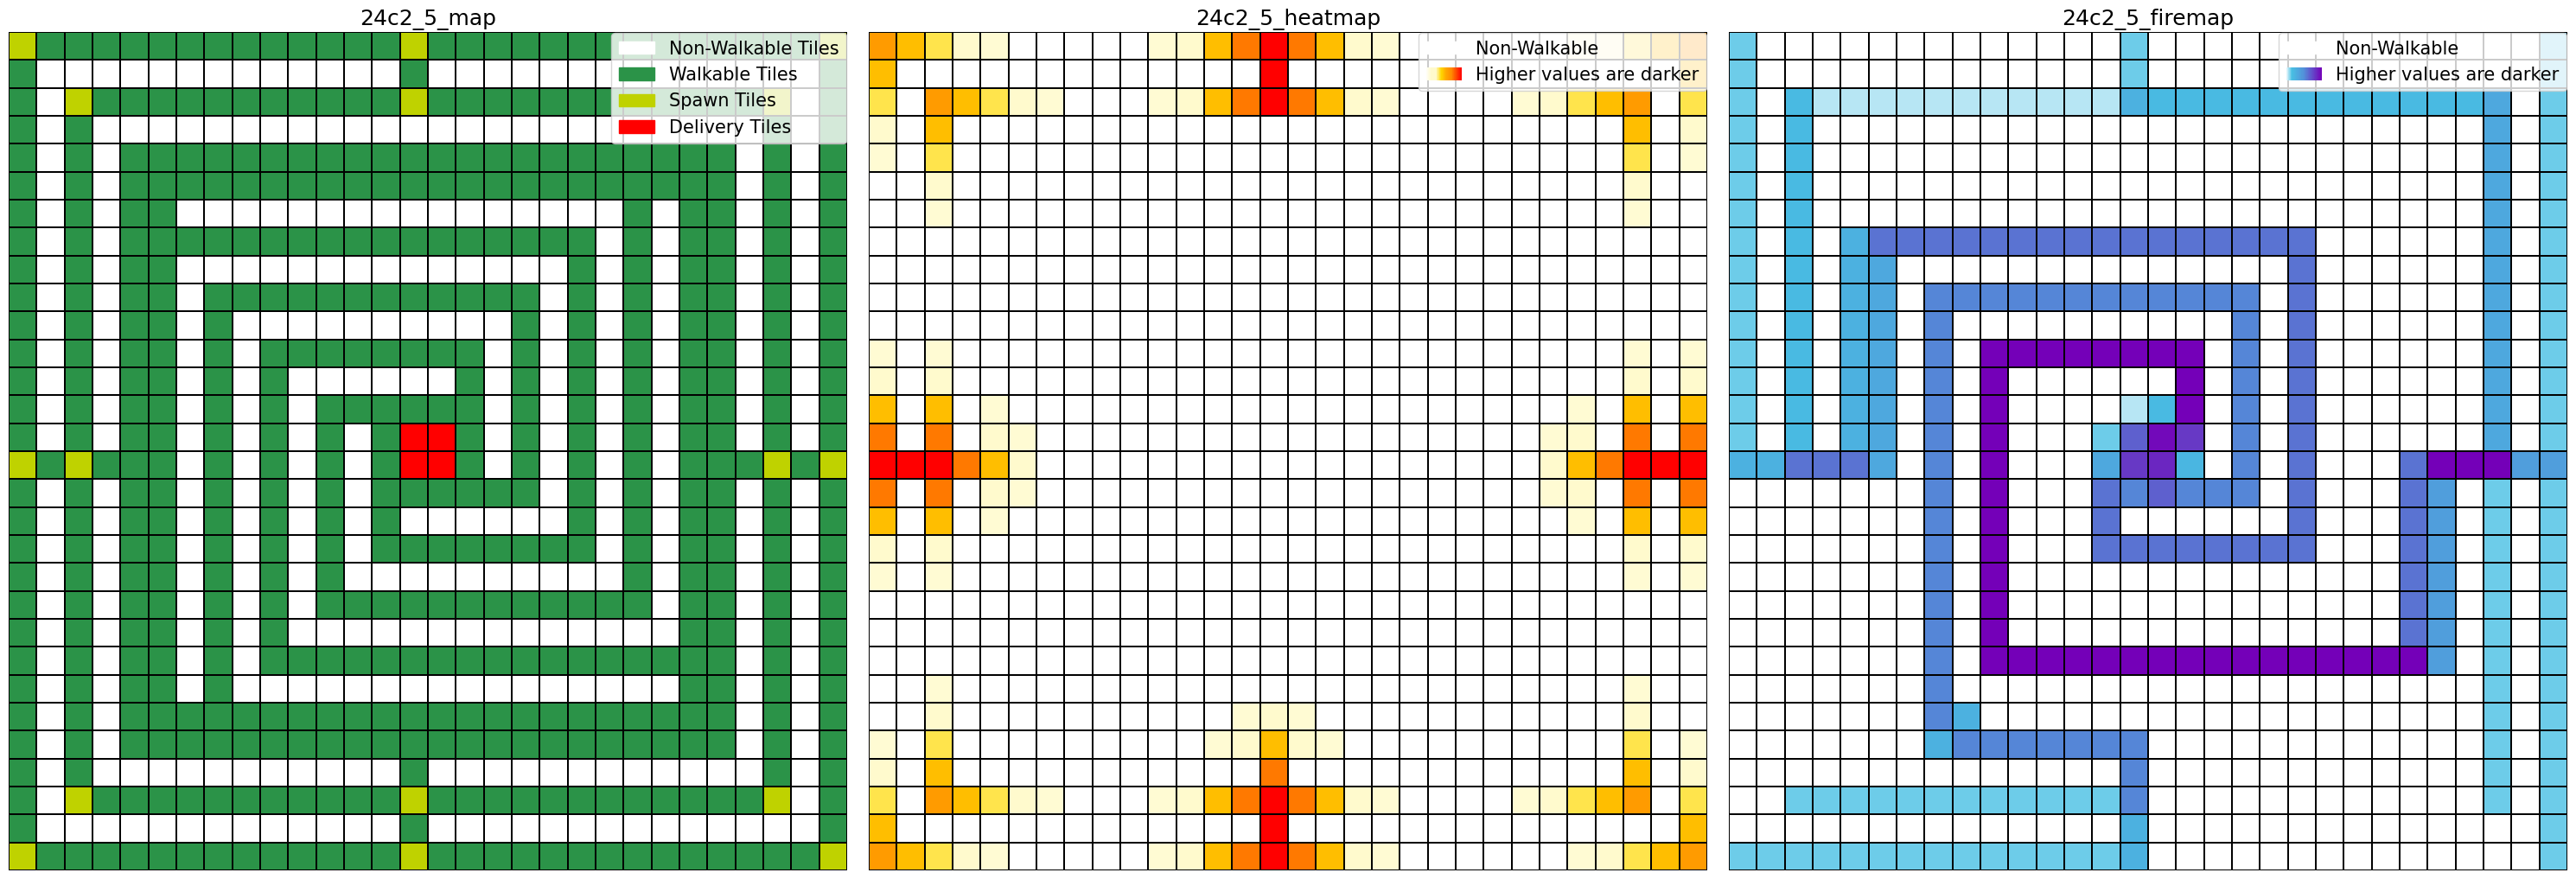

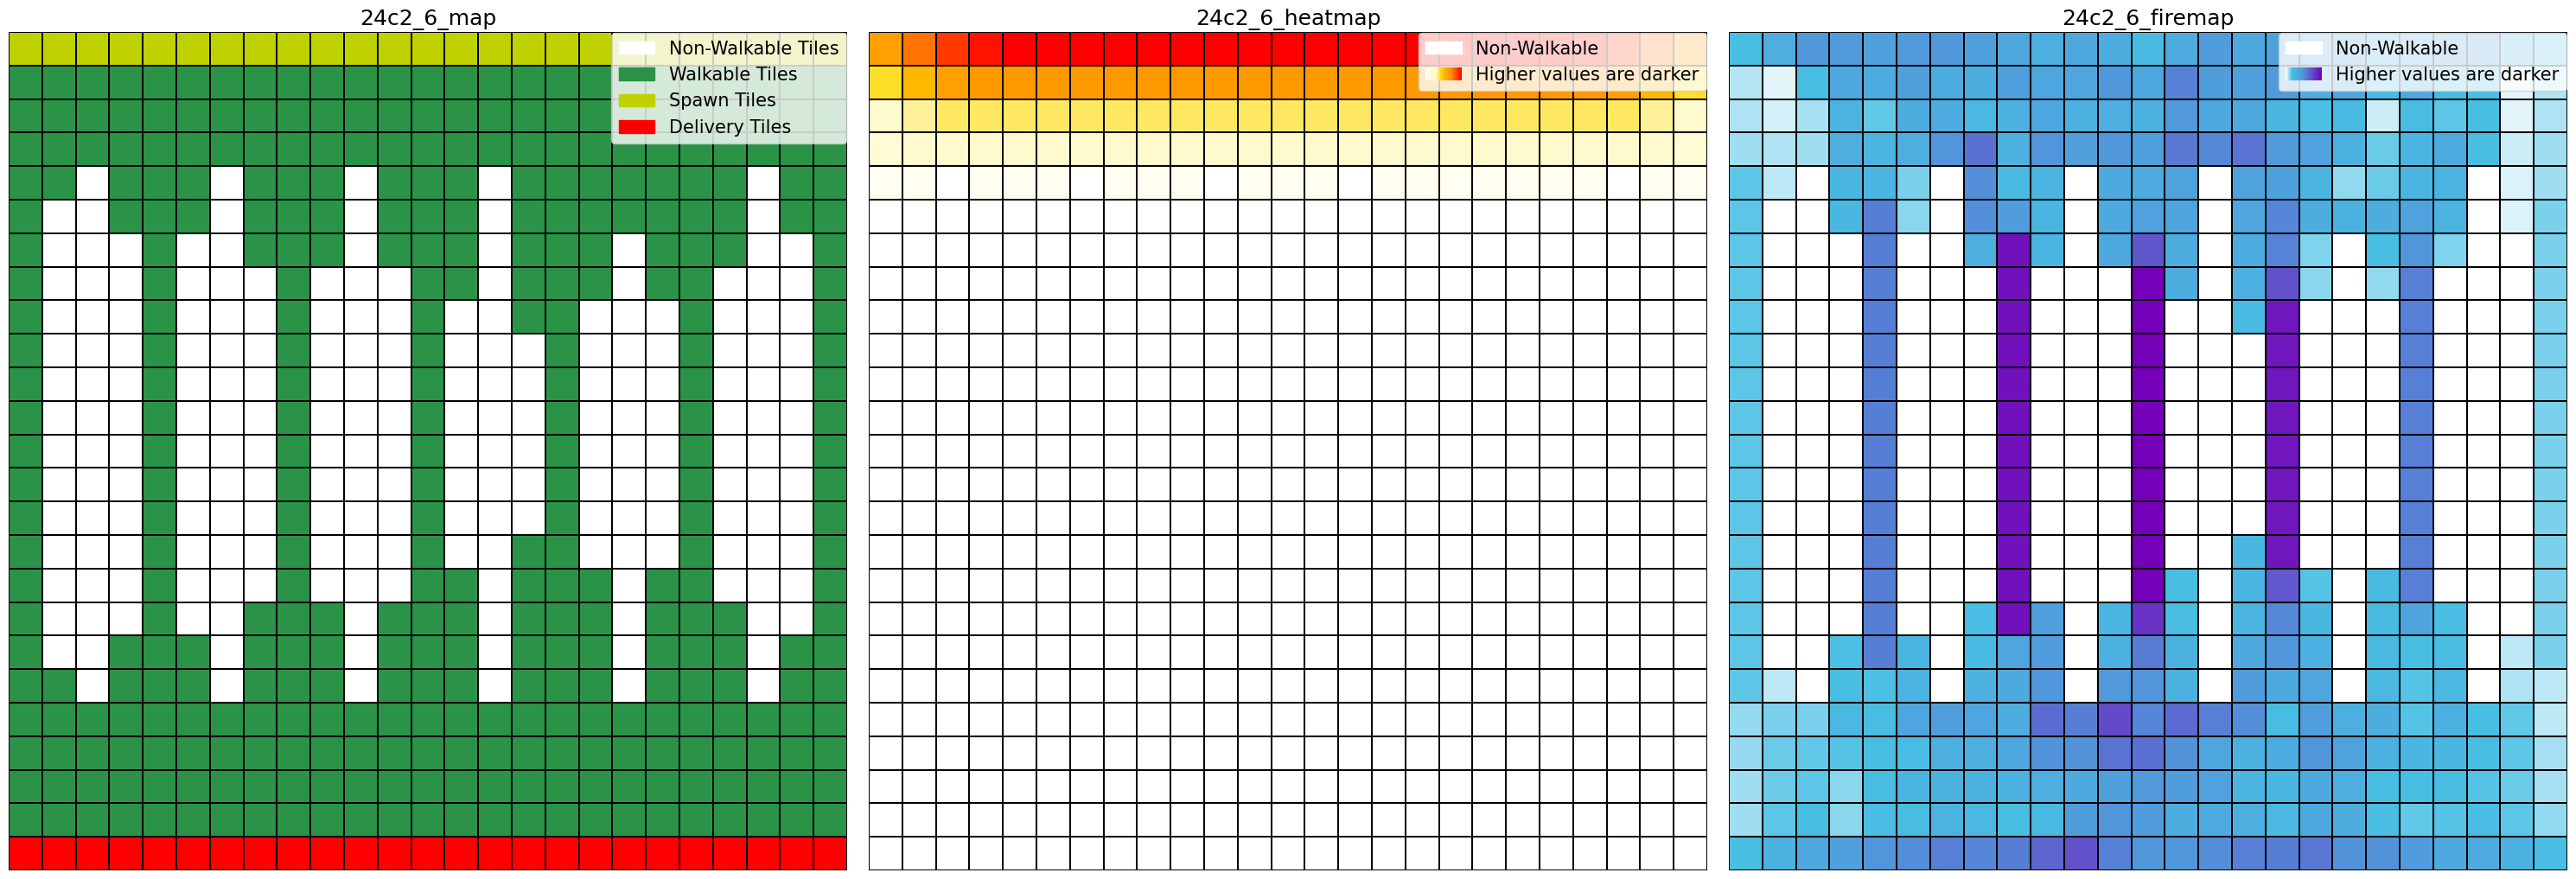

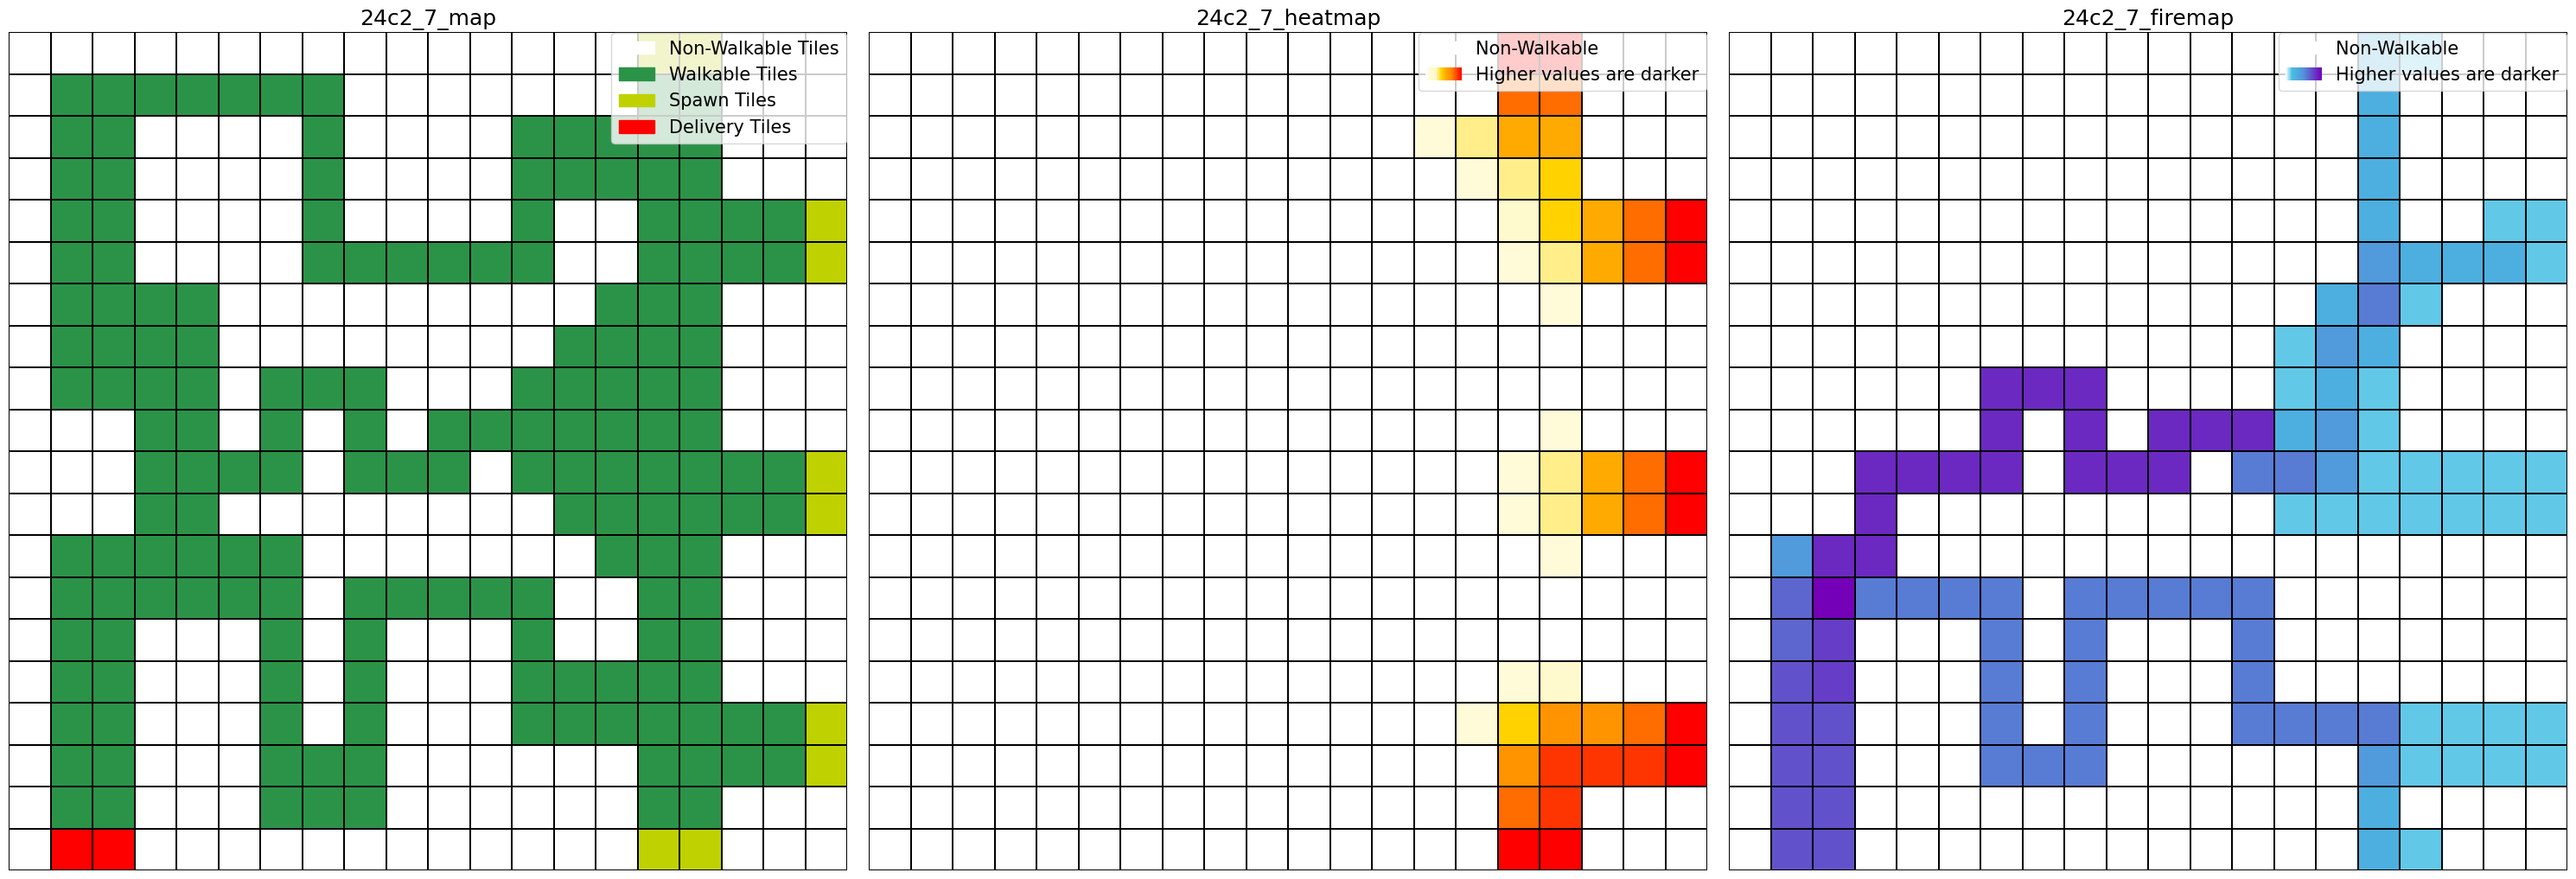

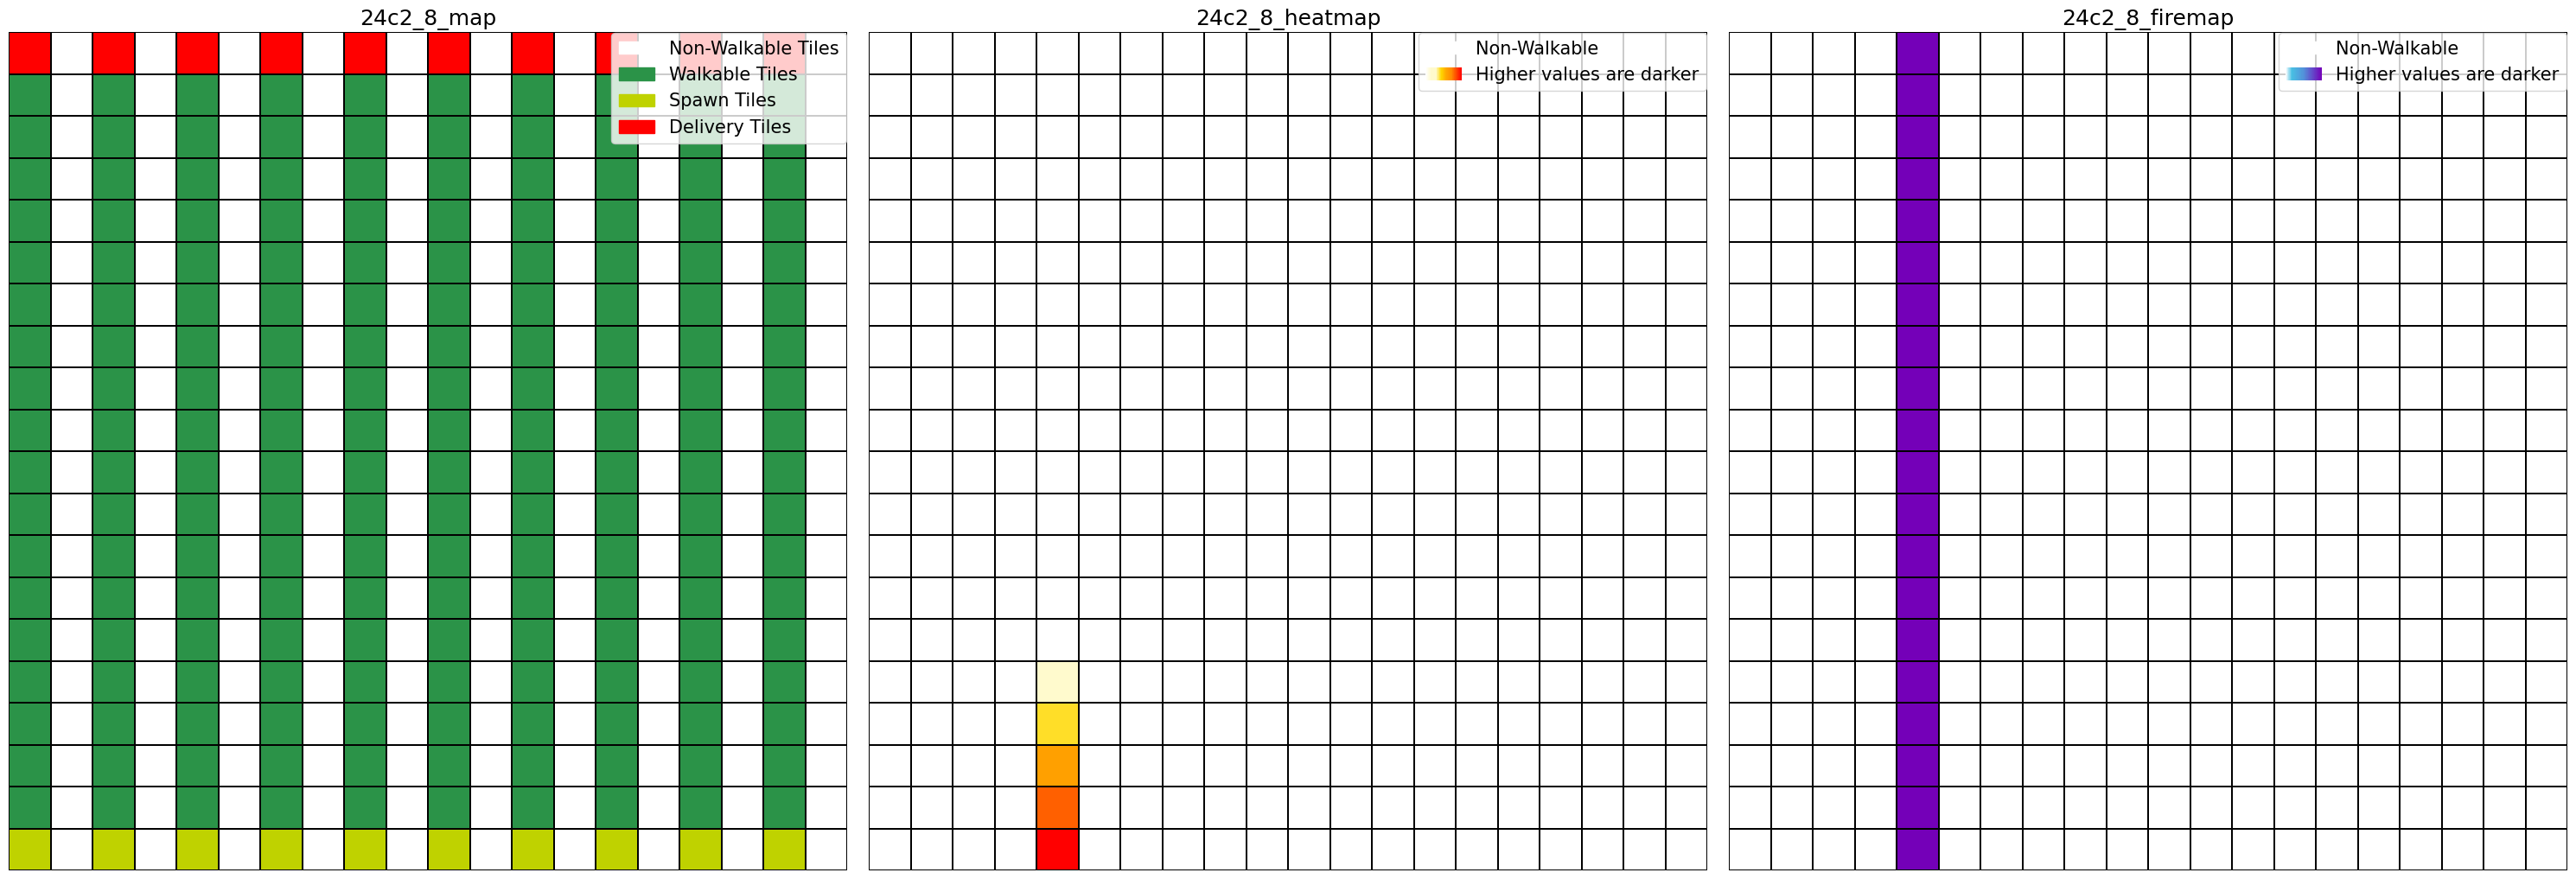

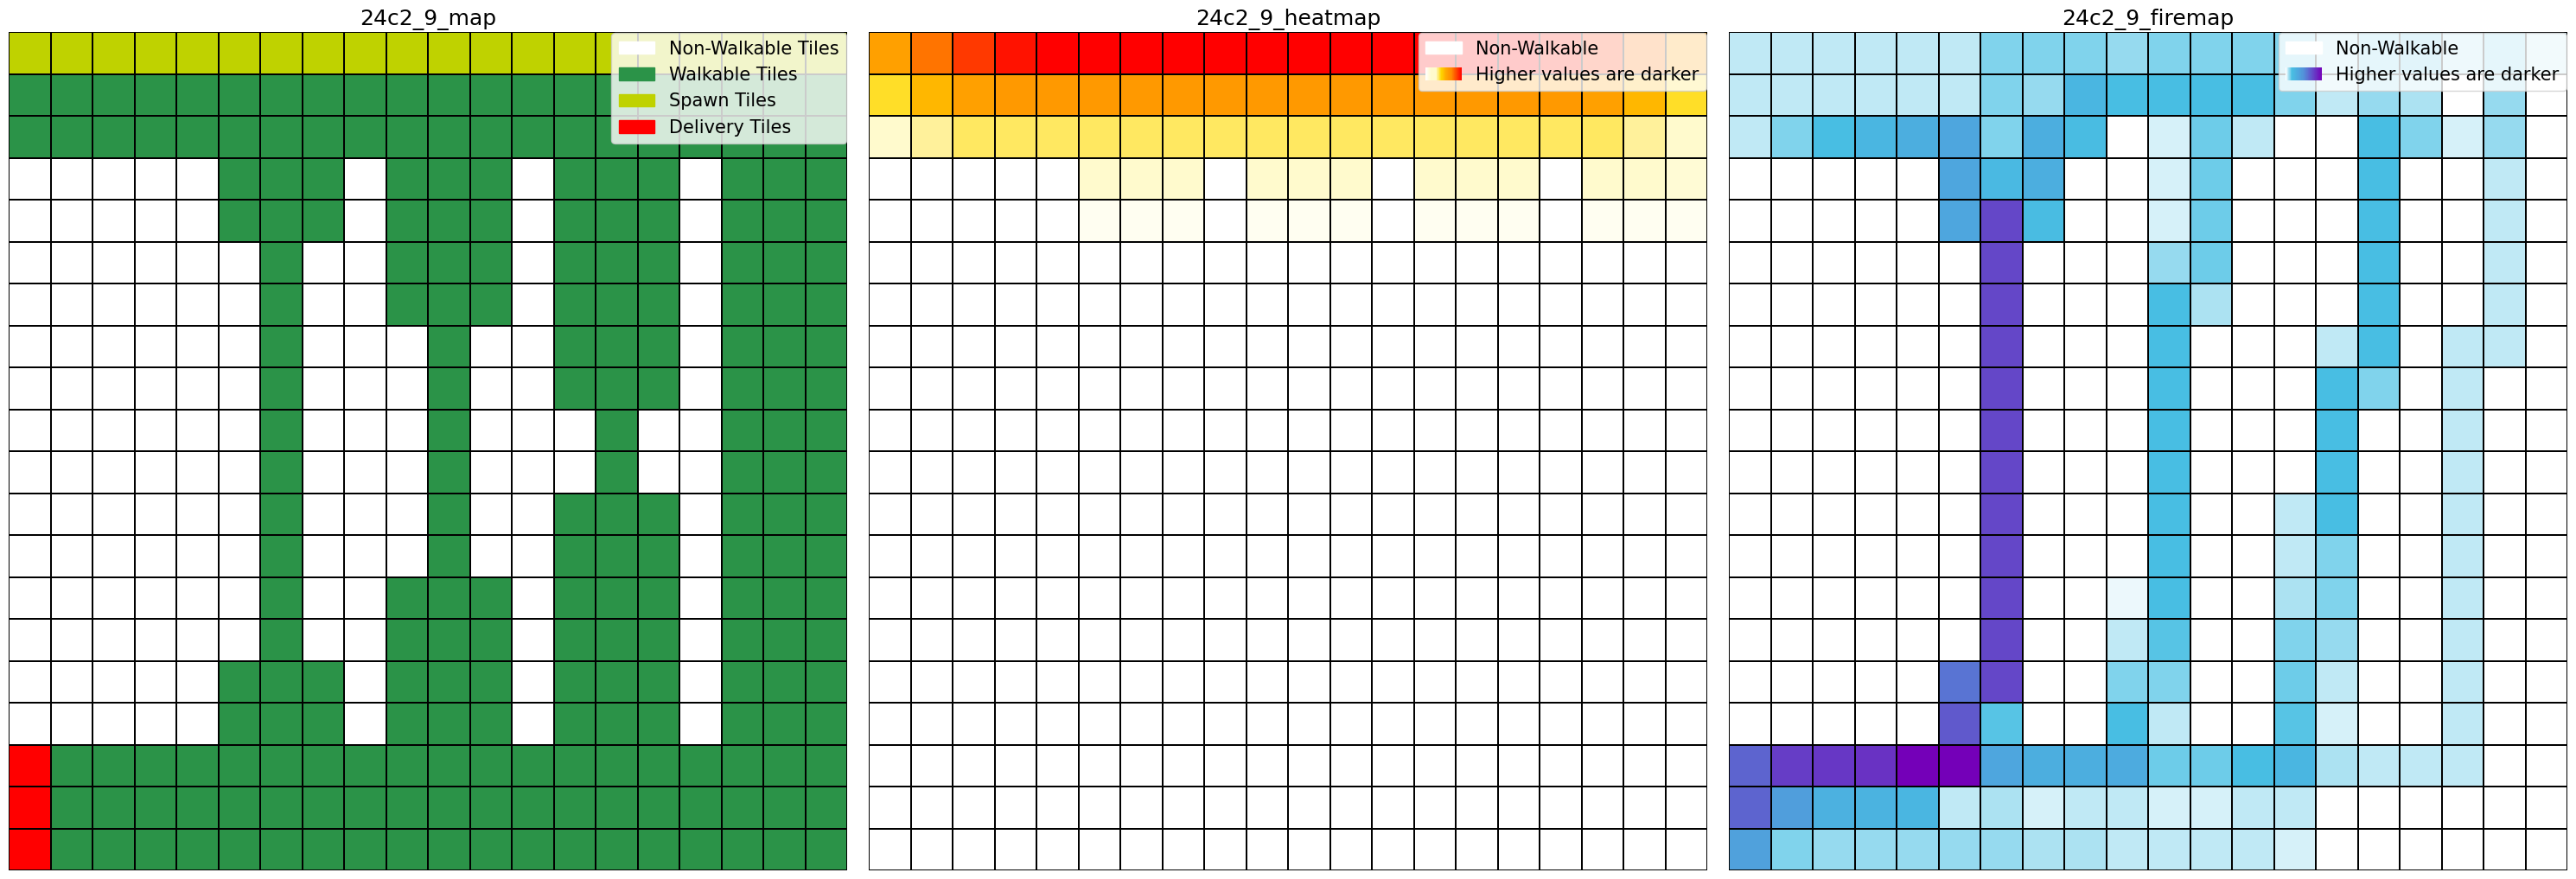

In [42]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
import numpy as np

# Custom handler to create a gradient legend box
class HandlerColormap(HandlerPatch):
    def __init__(self, cmap, num_stripes=100, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        stripes = []
        for i in range(self.num_stripes):
            stripe = mpatches.Rectangle([xdescent + i * width / self.num_stripes, ydescent], 
                                        width / self.num_stripes, height, 
                                        transform=trans, 
                                        edgecolor='none', 
                                        facecolor=self.cmap(i / self.num_stripes))
            stripes.append(stripe)
        return stripes

def plot(map_name :str = "24c1_5"):
    world_map_colors = ["#FFFFFF", "#2B9348", "#BFD200", "#ff0000"]
    heatmap_colors = ["#ff0000","#ff4500","#ff8c00","#ffa500","#ffd700","#fffacd","#fffacd","#FFFFFF"]
    traffic_heatmap_colors = ["#7400b8", "#6930c3", "#5e60ce", "#5390d9",  "#4ea8de", "#48bfe3", "#FFFFFF"]
    heatmap_colors.reverse()
    traffic_heatmap_colors.reverse()

    world_map_palette = LinearSegmentedColormap.from_list("world_map_palette", world_map_colors, N=4)
    heatmap_palette = LinearSegmentedColormap.from_list("heatmap_palette", heatmap_colors, N=400)
    traffic_heatmap_palette = LinearSegmentedColormap.from_list("traffic_heatmap_palette", traffic_heatmap_colors, N=400)

    palettes = [world_map_palette, heatmap_palette, traffic_heatmap_palette]
    file_names = [f'{map_name}_map', f'{map_name}_heatmap', f'{map_name}_firemap']
    colors = [world_map_colors, heatmap_colors, traffic_heatmap_colors]

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(30, 10))

    for ax, palette, file, color in zip(axes, palettes, file_names, colors):
        with open(f'{file}.json', 'r') as json_file:
            json_str = json_file.read()

        numeric_matrix = json.loads(json_str)
        numeric_matrix = [[int(element) for element in row] for row in numeric_matrix]
        numeric_matrix = np.rot90(np.array(numeric_matrix))

        # if file == f'{map_name}_heatmap':
        #     min_val = np.min(numeric_matrix)
        #     max_val = np.max(numeric_matrix)
        #     numeric_matrix = (numeric_matrix - min_val) / (max_val - min_val)

        #     color_matrix = np.empty(numeric_matrix.shape, dtype=int)

        #     for i in range(numeric_matrix.shape[0]):
        #         for j in range(numeric_matrix.shape[1]):
        #             normalized_value = numeric_matrix[i, j]
        #             color_index = np.clip(int(normalized_value * (len(color) - 1)), 0, len(color) - 1)
        #             color_matrix[i, j] = color_index

        #     numeric_matrix = color_matrix

        # Ensure correct color mapping for the world map
        if file == f'{map_name}_map':
            for value in range(len(world_map_colors)):
                numeric_matrix = np.where(numeric_matrix == value, value, numeric_matrix)

        norm = Normalize(vmin=0, vmax=np.max(numeric_matrix))

        sns.heatmap(numeric_matrix, cmap=palette, norm=norm, annot=False, cbar=False, square=True, linewidths=0.01, linecolor='black', ax=ax)
        
        ax.set_title(file, fontsize=18) 
        ax.set_xticks([])
        ax.set_yticks([])

        # Add custom labels
        if file == f'{map_name}_map':
            labels = {
                "#FFFFFF": "Non-Walkable Tiles",
                "#2B9348": "Walkable Tiles",
                "#BFD200": "Spawn Tiles",
                "#ff0000": "Delivery Tiles"
            }
            patches = [mpatches.Patch(color=color, label=label) for color, label in labels.items()]
            ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(0.999, 0.999), borderaxespad=0, fontsize=15)
        else:
            gradient_legend_patch = mpatches.Patch(color='none', label='Higher values are darker')
            non_walkable_patch = mpatches.Patch(color="#FFFFFF", label="Non-Walkable")
            
            handler_cmap = HandlerColormap(heatmap_palette if file == f'{map_name}_heatmap' else traffic_heatmap_palette)
        
            ax.legend(handles=[non_walkable_patch, gradient_legend_patch], 
            handler_map={gradient_legend_patch: handler_cmap, non_walkable_patch: HandlerPatch()}, 
            loc='upper right', bbox_to_anchor=(0.999, 0.999), borderaxespad=0, fontsize=15)

    plt.tight_layout()
    # plt.show()
    plt.savefig(f'{map_name}.png', dpi=300, bbox_inches="tight")

for map in [
    "24c1_1",
    "24c1_2",
    "24c1_3",
    "24c1_4",
    "24c1_5",
    "24c1_6",
    "24c1_7",
    "24c1_8",
    "24c1_9",
    "24c2_1",
    "24c2_2",
    "24c2_3",
    "24c2_4",
    "24c2_5",
    "24c2_6",
    "24c2_7",
    "24c2_8",
    "24c2_9",
]:
    plot(map)